# BC Regular Anti-Windup — Policy Evaluation
Rolls out `bc_regular_anti_windup_*.pt` policies in closed loop.

Controller matches `Main_aggresive.m` / `BC_Regular_Anti_Windup.py`:
* **positional** action — the network outputs `q` directly (not delta_q),
* **bumpless start** `int_e = (q0 - Kp*e0)/Ki`,
* **back-calculation anti-windup** `int_e += (e + Kw*(q_sat-q_raw))*Ts`, `Kw=Ki/Kp`,
* aggressive gains `Kp=-0.5`, `Ki=-0.5/300`, flow limits `0-40`.

T_ref auto: cloudy 65 C, sunny 80 C. **Run `BC_Regular_Anti_Windup.py` first.**

In [1]:
# ── Setup: shared library (../../main_script) + this folder's config ─────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
_here = os.getcwd()
PKG = os.path.dirname(_here) if os.path.basename(_here).lower() == "evaluate" else _here
sys.path.insert(0, PKG)                       # for config
sys.path.insert(0, os.path.dirname(PKG))      # For GitHub -> main_script
from main_script import *
import config_regular as cfg
from config_regular import *
configure(cfg)
BASE_DIR = PKG
SAVE_DIR  = cfg.SAVE_DIR
CHART_DIR = cfg.CHART_DIR; os.makedirs(CHART_DIR, exist_ok=True)

EVAL_DATASET = "20_10_2025__Cloudy_Closed_Loop.xlsx"
EVAL_LABEL   = "_".join(EVAL_DATASET.split("_")[:3])
TREF   = dataset_tref(EVAL_DATASET)
DQ_MAX = 10.0
GROUP_COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#9467bd"}
OBS_LOW_10D = OBS_LOW; OBS_HIGH_10D = OBS_HIGH
def normalize_obs_10d(state): return normalize_obs(state)
def RegularBCNet(in_dim=10): return FlowActor(in_dim=in_dim, q_min=Q_MIN, q_max=Q_MAX)

print("Setup via main_script | EVAL_DATASET:", EVAL_DATASET, "| TREF:", TREF)


Setup via main_script | EVAL_DATASET: 20_10_2025__Cloudy_Closed_Loop.xlsx | TREF: 65.0


In [2]:
# ── Load dataset from Excel ────────────────────────────────────────────────────
def load_dataset(filename):
    path = os.path.join(BASE_DIR, 'data', filename)
    df   = pd.read_excel(path)
    return dict(
        T_sc   = df['T_sc'].to_numpy(dtype=np.float64),
        Tin    = df['Tin'].to_numpy(dtype=np.float64),
        Ta     = df['Ta'].to_numpy(dtype=np.float64),
        I_sol  = df['I'].to_numpy(dtype=np.float64),
        theta  = df['theta'].to_numpy(dtype=np.float64),
        q      = df['q'].to_numpy(dtype=np.float64),
        time_ax= np.arange(len(df), dtype=np.float64) * TS,
        N      = len(df),
        name   = filename,
    )

data      = load_dataset(EVAL_DATASET)
T_sc_meas = data['T_sc']
time_ax   = data['time_ax']

print(f"Dataset  = {data['N']} steps  ({EVAL_DATASET})")
print(f"T_sc : mean={T_sc_meas.mean():.2f}°C  "
      f"min={T_sc_meas.min():.2f}°C  max={T_sc_meas.max():.2f}°C")
print(f"T_ref = {TREF}°C  (constant — {'cloudy' if TREF == TREF_CLOUDY else 'sunny'} dataset)")

Dataset  = 19801 steps  (20_10_2025__Cloudy_Closed_Loop.xlsx)
T_sc : mean=58.58°C  min=45.10°C  max=69.60°C
T_ref = 65.0°C  (constant — cloudy dataset)


In [3]:
# ── Discover all BC Regular Anti-Windup policies ────────────────────────────────────
bc_files = sorted([
    f for f in os.listdir(SAVE_DIR)
    if f.startswith('bc_regular_anti_windup_') and f.endswith('.pt')
    and not f.endswith('_best.pt')
])

policies = []
for fname in bc_files:
    combo_name = fname.replace('bc_regular_anti_windup_', '').replace('.pt', '')
    days = [d for d in combo_name.split('_') if d.startswith('s')]
    policies.append({
        'fname':      fname,
        'path':       os.path.join(SAVE_DIR, fname),
        'combo_name': combo_name,
        'days':       days,
        'n_files':    len(days),
    })

print(f"Found {len(policies)} BC Regular Anti-Windup policies:")
for p in policies:
    print(f"  [{p['n_files']}d]  {p['fname']}")

Found 15 BC Regular Anti-Windup policies:
  [1d]  bc_regular_anti_windup_s21.pt
  [2d]  bc_regular_anti_windup_s21_s22.pt
  [3d]  bc_regular_anti_windup_s21_s22_s23.pt
  [4d]  bc_regular_anti_windup_s21_s22_s23_s24.pt
  [3d]  bc_regular_anti_windup_s21_s22_s24.pt
  [2d]  bc_regular_anti_windup_s21_s23.pt
  [3d]  bc_regular_anti_windup_s21_s23_s24.pt
  [2d]  bc_regular_anti_windup_s21_s24.pt
  [1d]  bc_regular_anti_windup_s22.pt
  [2d]  bc_regular_anti_windup_s22_s23.pt
  [3d]  bc_regular_anti_windup_s22_s23_s24.pt
  [2d]  bc_regular_anti_windup_s22_s24.pt
  [1d]  bc_regular_anti_windup_s23.pt
  [2d]  bc_regular_anti_windup_s23_s24.pt
  [1d]  bc_regular_anti_windup_s24.pt


In [4]:
# ── Rollout helpers — positional PI, bumpless start, back-calculation anti-windup
def rollout_expert(data, tref=None):
    if tref is None:
        tref = dataset_tref(data['name'])
    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']
    th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout
    int_e = (float(qm[0]) - KP_EXPERT * (tref - tout)) / KI_EXPERT   # bumpless: q_raw(0)=q0
    Tout_list=[]; q_list=[]
    for t in range(N - 1):
        e  = tref - tout
        de = -(tout - tout_prev) / TS
        u  = KP_EXPERT * e + KI_EXPERT * int_e + KD_EXPERT * de
        q_raw = u
        q  = float(np.clip(q_raw, Q_MIN, Q_MAX))
        int_e = float(np.clip(int_e + (e + KW * (q - q_raw)) * TS, -INT_E_CLIP, INT_E_CLIP))
        tout_next = solar_model(q, Tin[t], I[t], Ta[t], th[t], tout)
        Tout_list.append(tout_next); q_list.append(q)
        tout_prev = tout; tout = tout_next
    return np.array(Tout_list), np.array(q_list)


def rollout_bc_regular_anti_windup(weights_path, data, tref=None):
    if tref is None:
        tref = dataset_tref(data['name'])
    model = RegularBCNet(in_dim=10)
    model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    model.eval()

    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']
    th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout; q_prev=float(qm[0])
    int_e = (q_prev - KP_EXPERT * (tref - tout)) / KI_EXPERT   # bumpless start
    Tout_list=[]; q_list=[]; dq_list=[]

    with torch.no_grad():
        for t in range(N - 1):
            e  = tref - tout
            de = -(tout - tout_prev) / TS
            state  = np.array([tout, e, int_e, de, I[t], Ta[t], Tin[t], th[t], q_prev, tref],
                               dtype=np.float32)
            s_norm = torch.from_numpy(normalize_obs_10d(state).reshape(1, -1))
            q_raw  = float(model(s_norm).item())          # positional q
            q      = float(np.clip(q_raw, Q_MIN, Q_MAX))
            tout_next = solar_model(q, Tin[t], I[t], Ta[t], th[t], tout)
            Tout_list.append(tout_next); q_list.append(q); dq_list.append(q - q_prev)
            int_e = float(np.clip(int_e + (e + KW * (q - q_raw)) * TS, -INT_E_CLIP, INT_E_CLIP))
            tout_prev = tout; tout = tout_next; q_prev = q

    return np.array(Tout_list), np.array(q_list), np.array(dq_list)


# ── Run Expert PI (reference) ──
Tout_exp, q_exp = rollout_expert(data)
err_exp = Tout_exp - TREF
print(f"Expert PI   MAE={np.mean(np.abs(err_exp)):.4f}  "
      f"RMSE={np.sqrt(np.mean(err_exp**2)):.4f}  (vs T_ref={TREF})")

# ── Run all BC Regular Anti-Windup policies ──
results = {}
for p in policies:
    combo = p['combo_name']
    print(f"  Rolling out {combo} ...", end='  ', flush=True)
    Tout, q, dq_arr = rollout_bc_regular_anti_windup(p['path'], data)
    err   = Tout - TREF
    mae   = float(np.mean(np.abs(err)))
    rmse  = float(np.sqrt(np.mean(err ** 2)))
    max_e = float(np.max(np.abs(err)))
    results[combo] = {
        'Tout': Tout, 'q': q, 'error': err, 'dq': dq_arr,
        'mae': mae, 'rmse': rmse, 'max_e': max_e,
        'dq_mean': float(np.mean(np.abs(dq_arr))),
        'dq_std':  float(np.std(dq_arr)),
        'n_files': p['n_files'],
    }
    print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  "
          f"|dq|_mean={results[combo]['dq_mean']:.4f}  dq_std={results[combo]['dq_std']:.4f}")

print("\nAll rollouts complete.")

Expert PI   MAE=2.1095  RMSE=2.9148  (vs T_ref=65.0)
  Rolling out s21 ...  

MAE=2.015  RMSE=2.810  |dq|_mean=0.0120  dq_std=0.0203
  Rolling out s21_s22 ...  

MAE=2.222  RMSE=3.047  |dq|_mean=0.0144  dq_std=0.0233
  Rolling out s21_s22_s23 ...  

MAE=2.161  RMSE=2.952  |dq|_mean=0.0149  dq_std=0.0249
  Rolling out s21_s22_s23_s24 ...  

MAE=2.108  RMSE=2.872  |dq|_mean=0.0118  dq_std=0.0213
  Rolling out s21_s22_s24 ...  

...

MAE=2.226  RMSE=3.061  |dq|_mean=0.0137  dq_std=0.0233
  Rolling out s22_s24 ...  

MAE=2.319  RMSE=3.160  |dq|_mean=0.0104  dq_std=0.0183
  Rolling out s23 ...  

MAE=2.188  RMSE=2.998  |dq|_mean=0.0111  dq_std=0.0190
  Rolling out s23_s24 ...  

MAE=2.198  RMSE=3.042  |dq|_mean=0.0125  dq_std=0.0220
  Rolling out s24 ...  

MAE=2.145  RMSE=2.949  |dq|_mean=0.0110  dq_std=0.0207

All rollouts complete.


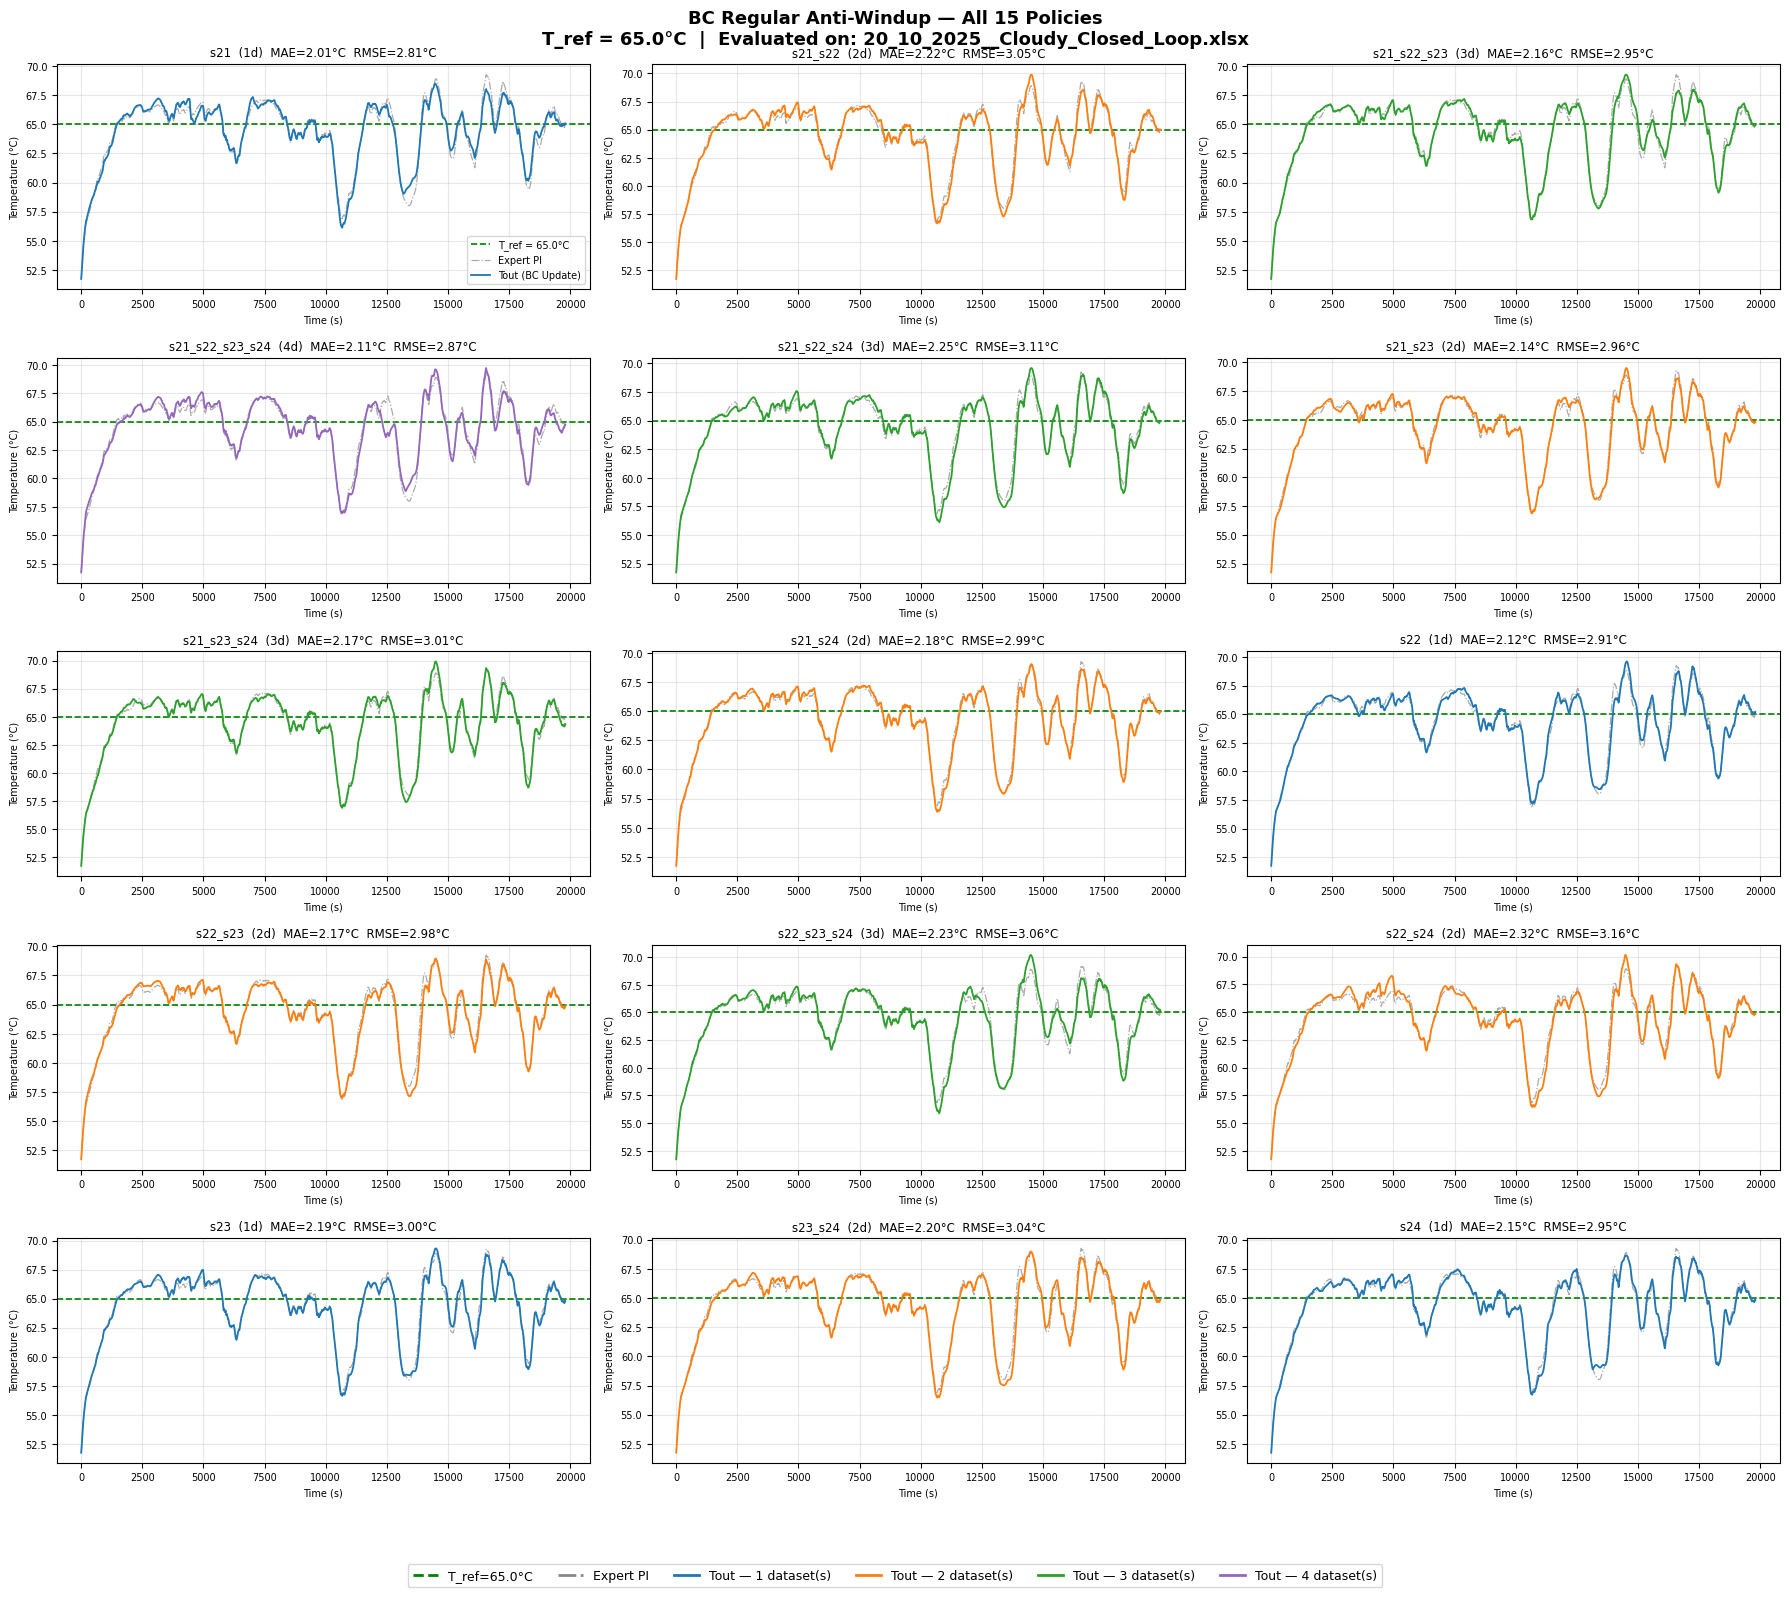

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_20_10_2025.png


In [5]:
# ── 5×3 grid: T_ref + Expert PI + Tout vs time (single EVAL_DATASET) ──────────
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
axes = axes.flatten()

for idx, p in enumerate(policies):
    combo = p['combo_name']
    ax    = axes[idx]

    if combo not in results:
        ax.set_title(f'{combo}  [no weights]', fontsize=9)
        ax.axis('off')
        continue

    r    = results[combo]
    Tout = r['Tout']
    t    = time_ax[1 : len(Tout) + 1]

    ax.axhline(TREF, color='green', linewidth=1.2, linestyle='--',
               label=f'T_ref = {TREF}°C')
    ax.plot(t, Tout_exp[:len(Tout)],
            color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7, label='Expert PI')
    ax.plot(t, Tout,
            color=GROUP_COLORS.get(p['n_files'], '#333333'), linewidth=1.3,
            label='Tout (BC Update)')
    ax.set_title(
        f"{combo}  ({p['n_files']}d)"
        f"  MAE={r['mae']:.2f}°C  RMSE={r['rmse']:.2f}°C",
        fontsize=8.5,
    )
    ax.set_ylabel('Temperature (°C)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, loc='best')

for ax in axes[len(policies):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
color_handles = [
    Line2D([0],[0], color=GROUP_COLORS[n], linewidth=2, label=f'Tout — {n} dataset(s)')
    for n in sorted(GROUP_COLORS)
]
type_handles = [
    Line2D([0],[0], color='green',   linewidth=2, linestyle='--', label=f'T_ref={TREF}°C'),
    Line2D([0],[0], color='#888888', linewidth=2, linestyle='-.', label='Expert PI'),
]
fig.legend(handles=type_handles + color_handles,
           loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    f'BC Regular Anti-Windup — All {len(policies)} Policies\n'
    f'T_ref = {TREF}°C  |  Evaluated on: {EVAL_DATASET}',
    fontsize=13, fontweight='bold',
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
out = os.path.join(CHART_DIR, f'bc_regular_anti_windup_grid_{EVAL_LABEL}.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

Running rollouts for all policies on all 5 datasets...
  (T_ref auto-selected: cloudy→65°C, sunny→80°C)



  s21                     avg MAE=1.566°C


  s21_s22                 avg MAE=1.697°C


  s21_s22_s23             avg MAE=1.441°C


  s21_s22_s23_s24         avg MAE=1.411°C


...

  s22_s23_s24             avg MAE=1.488°C


  s22_s24                 avg MAE=1.586°C


  s23                     avg MAE=1.525°C


  s23_s24                 avg MAE=1.629°C


  s24                     avg MAE=1.615°C

Best-generalising policy (lowest avg MAE across all 5 datasets): s21_s24  (avg MAE=1.3842°C)

All rollouts done.


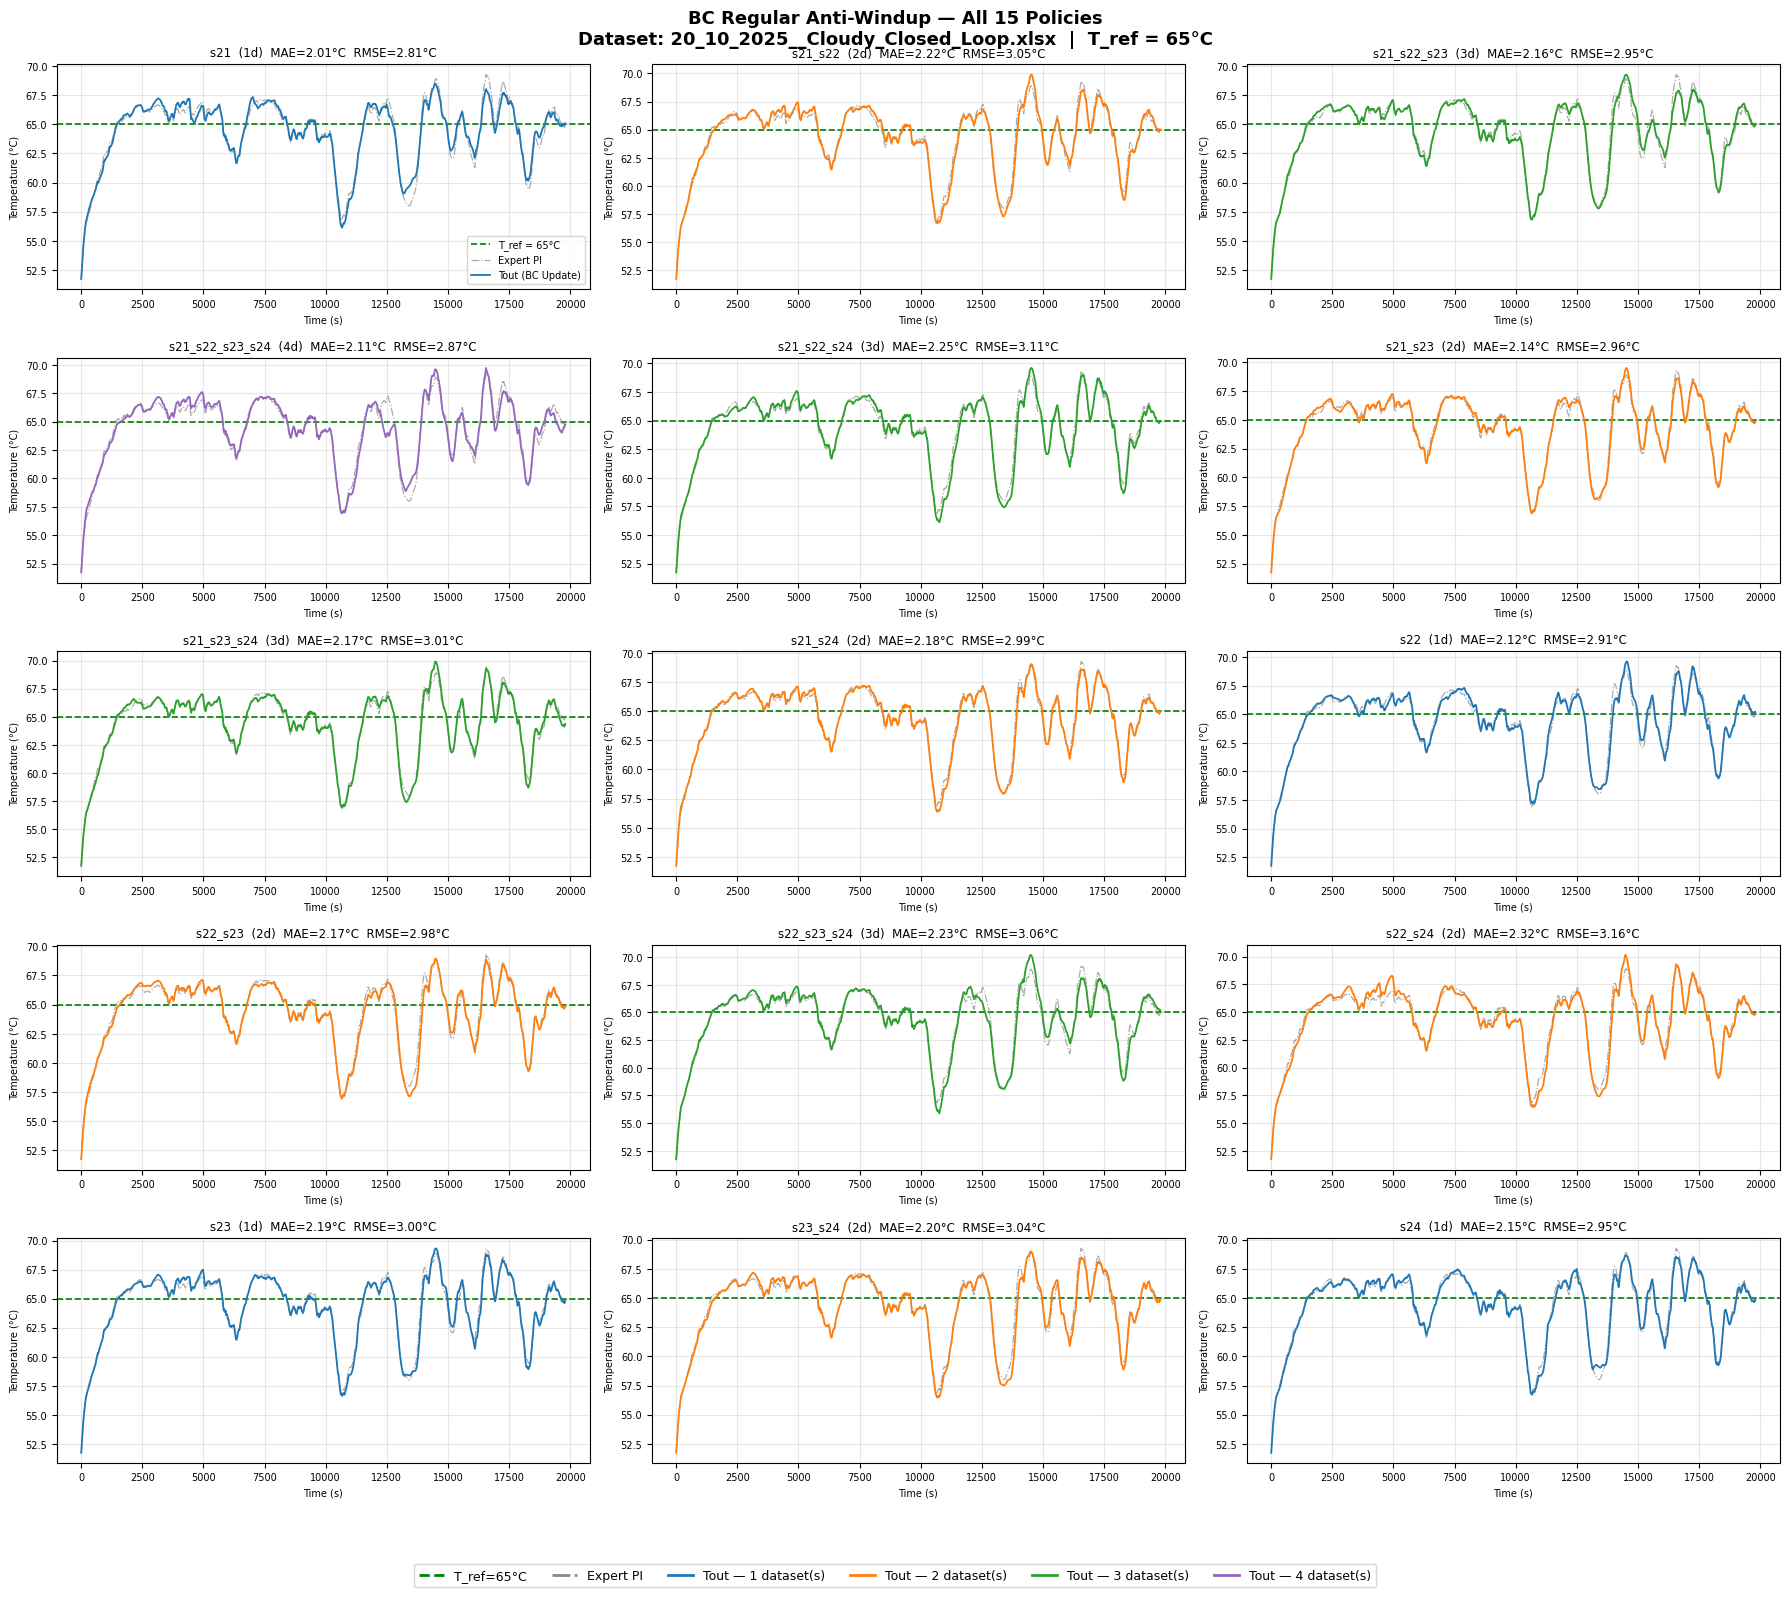

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_s20_65C.png


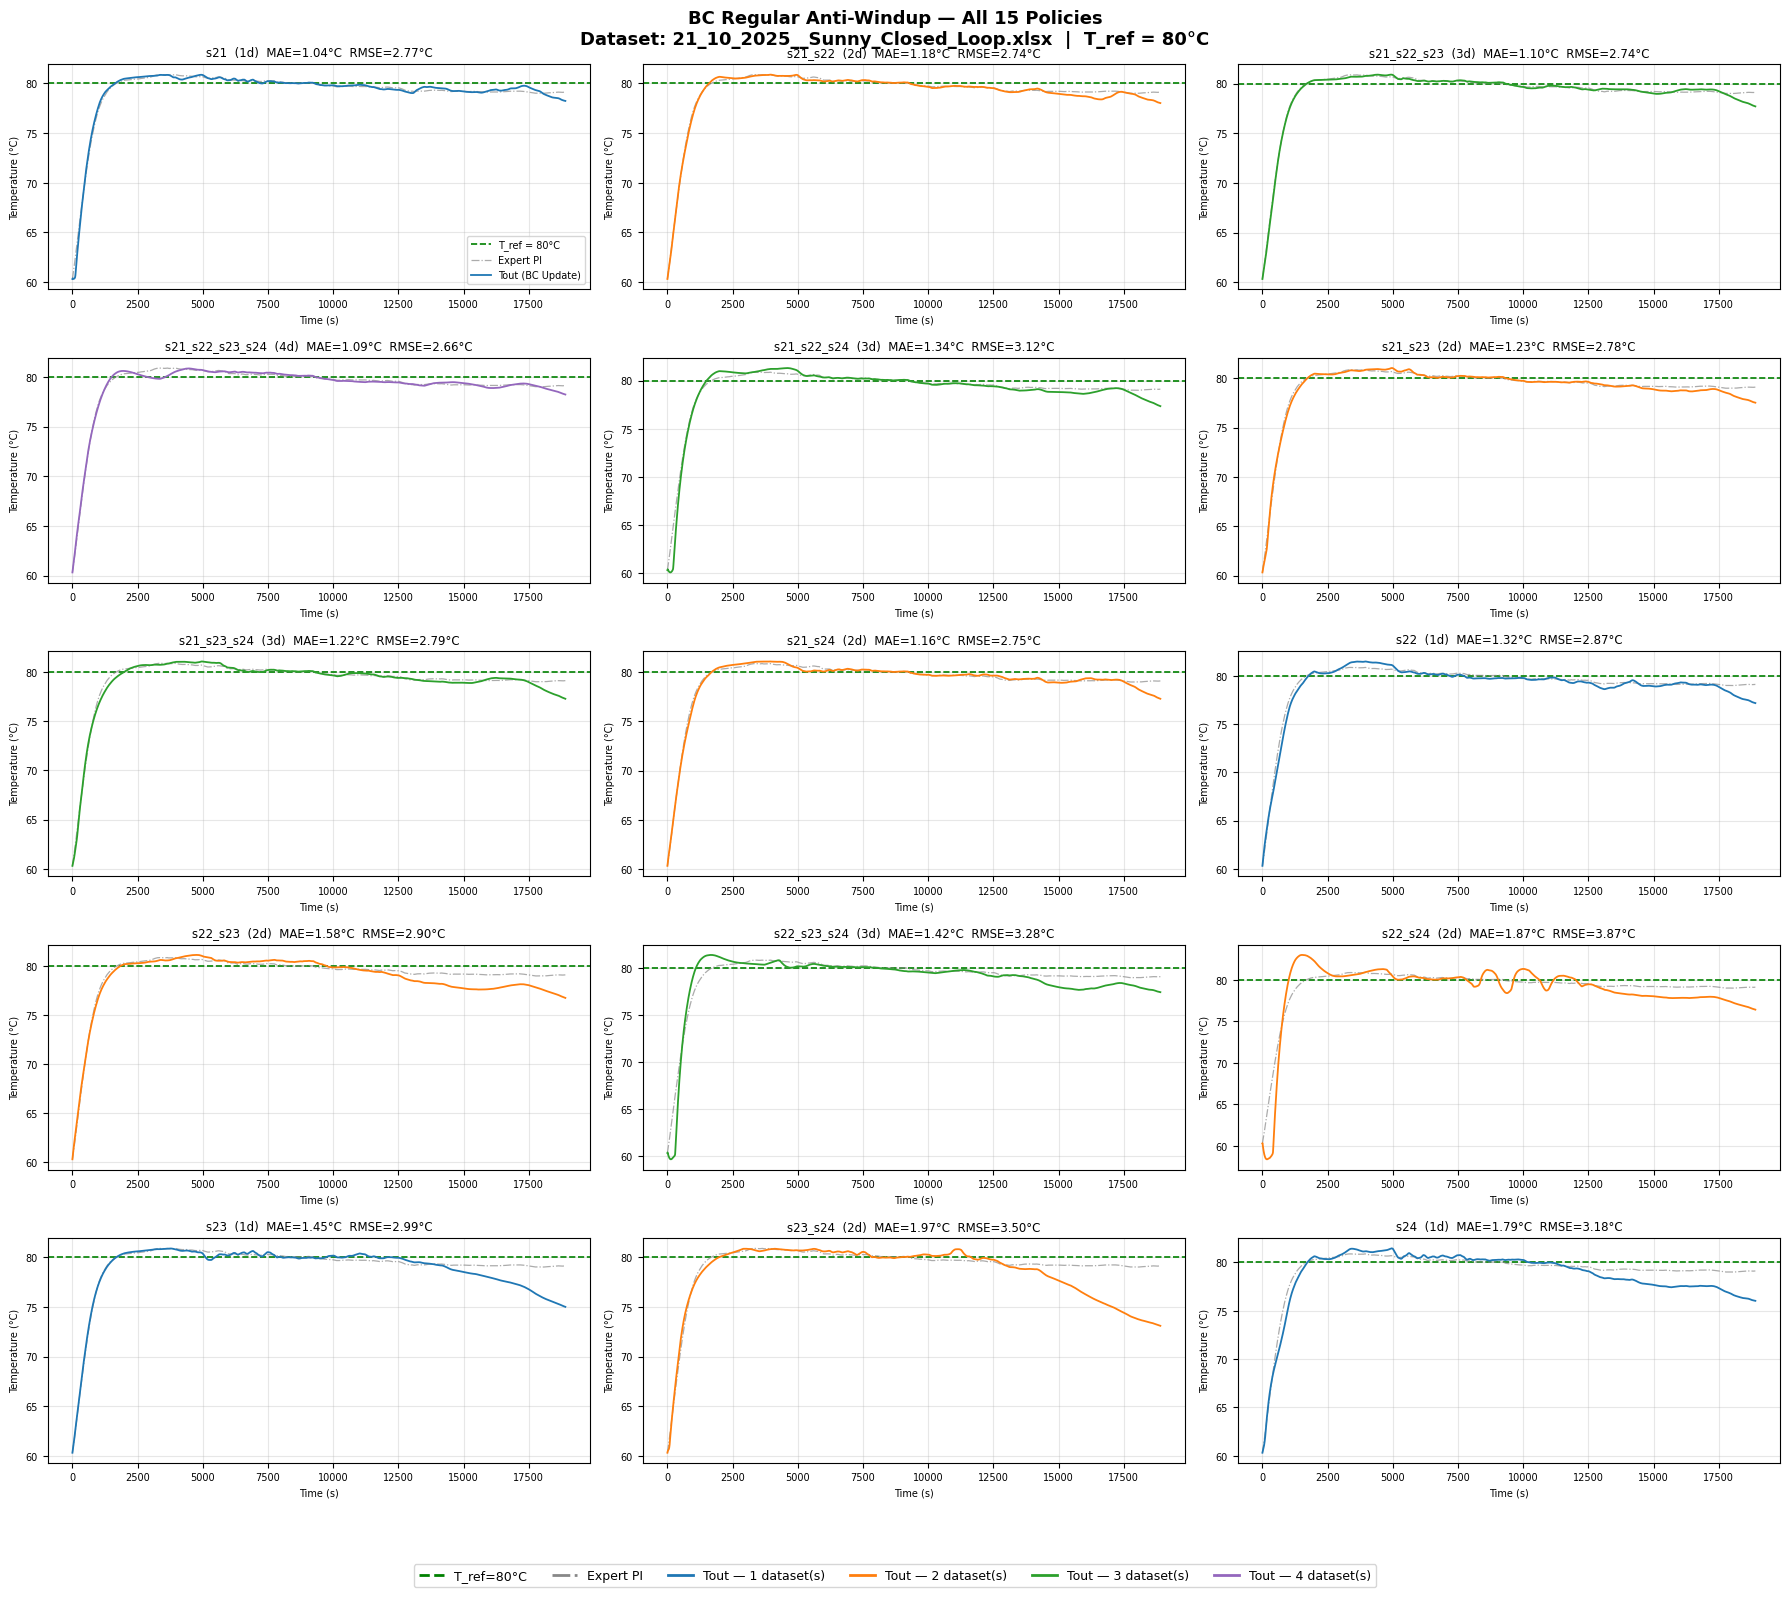

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_s21_80C.png


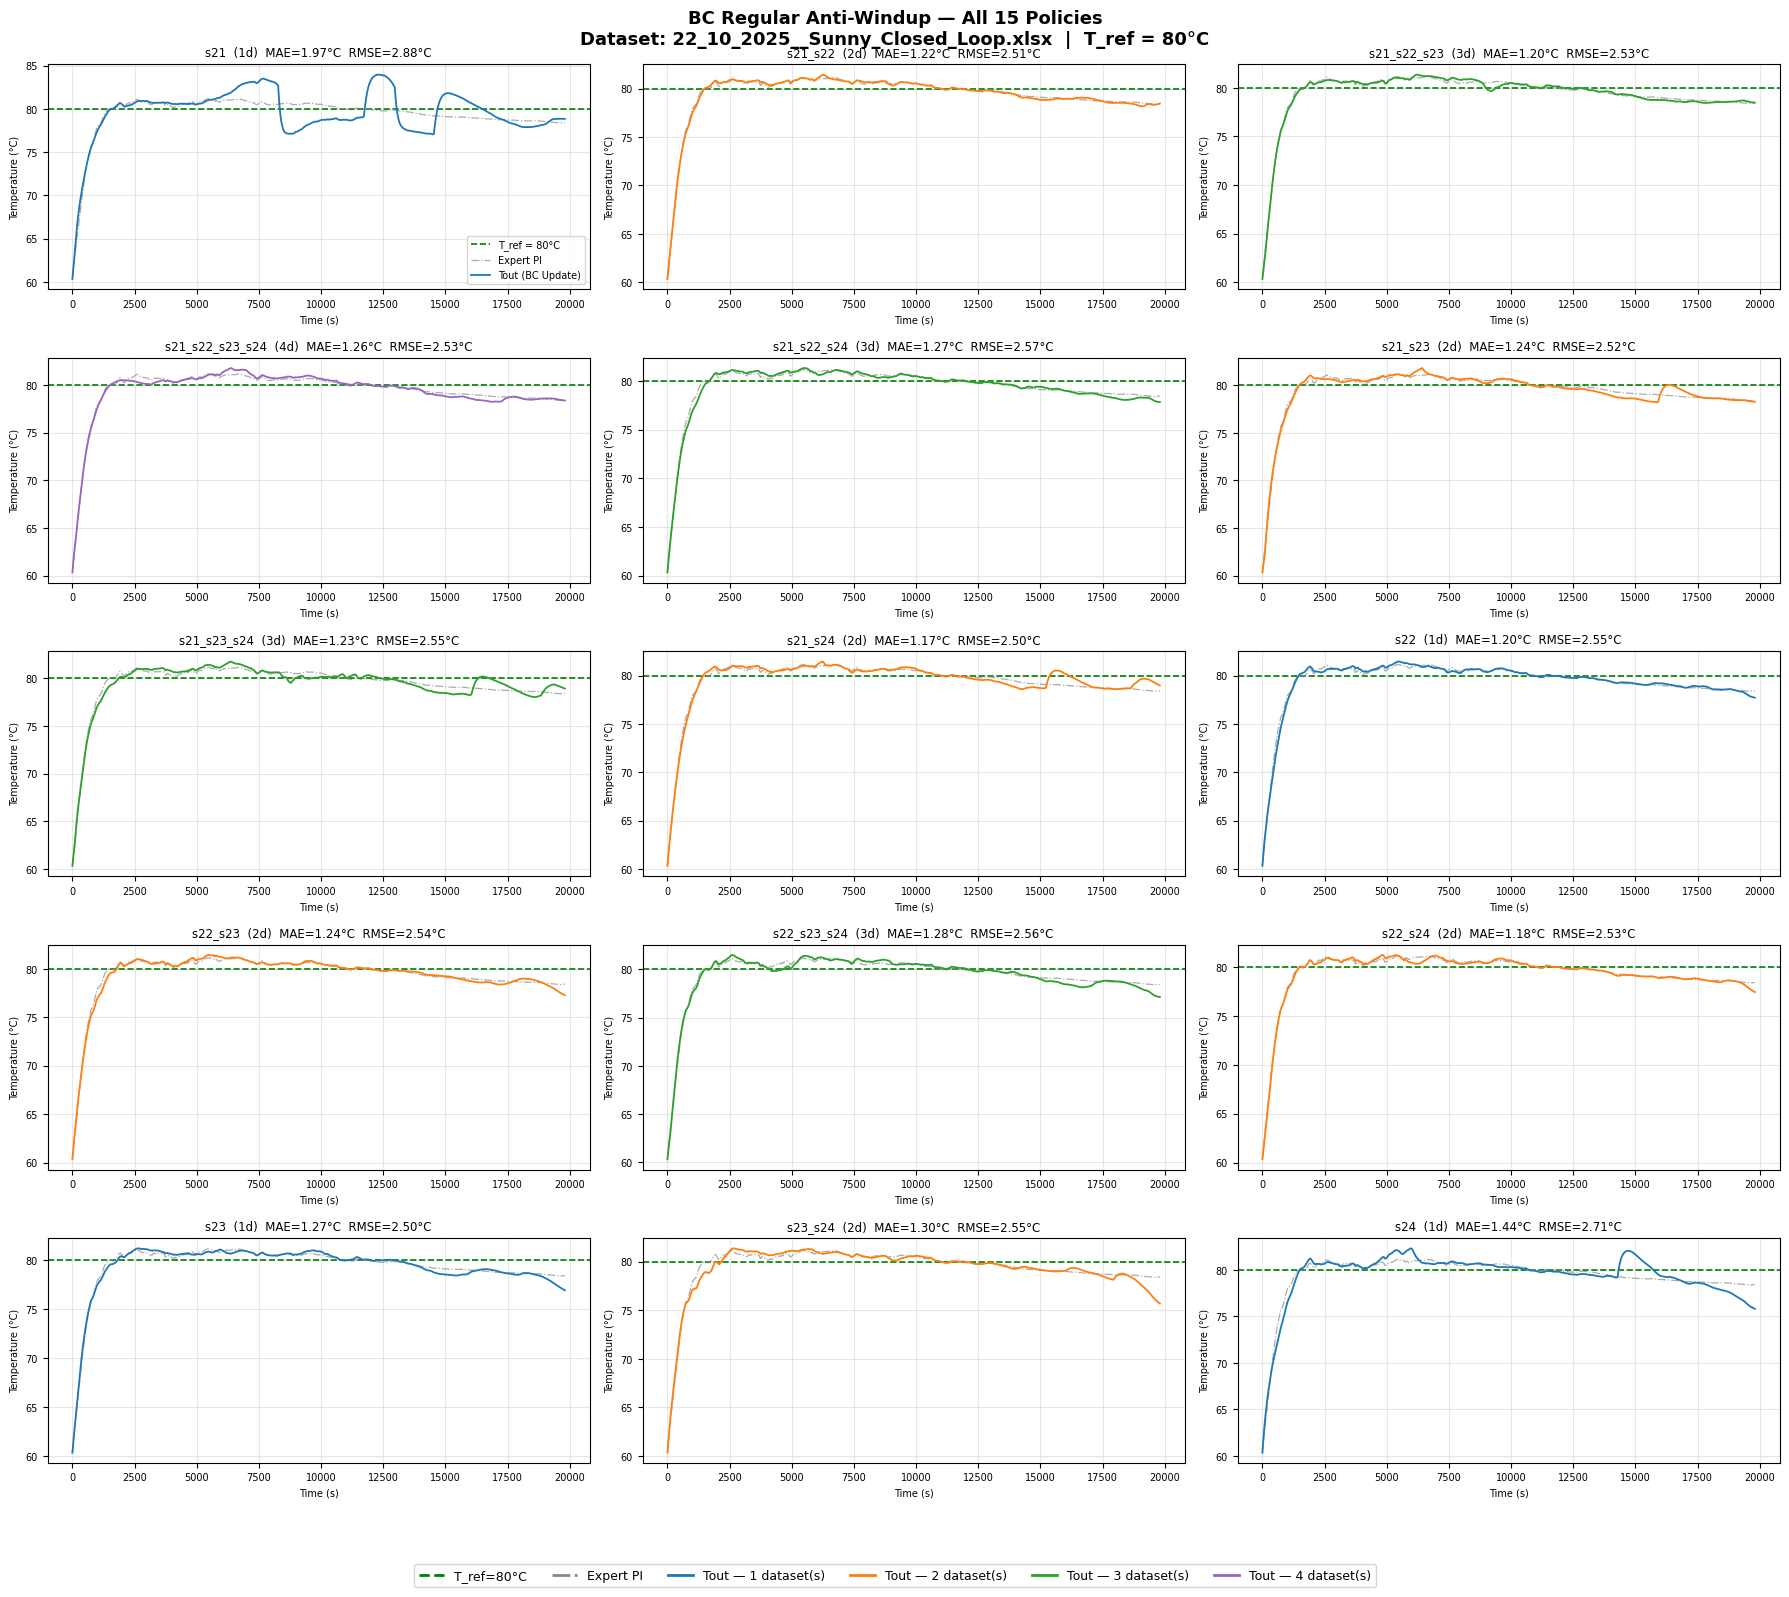

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_s22_80C.png


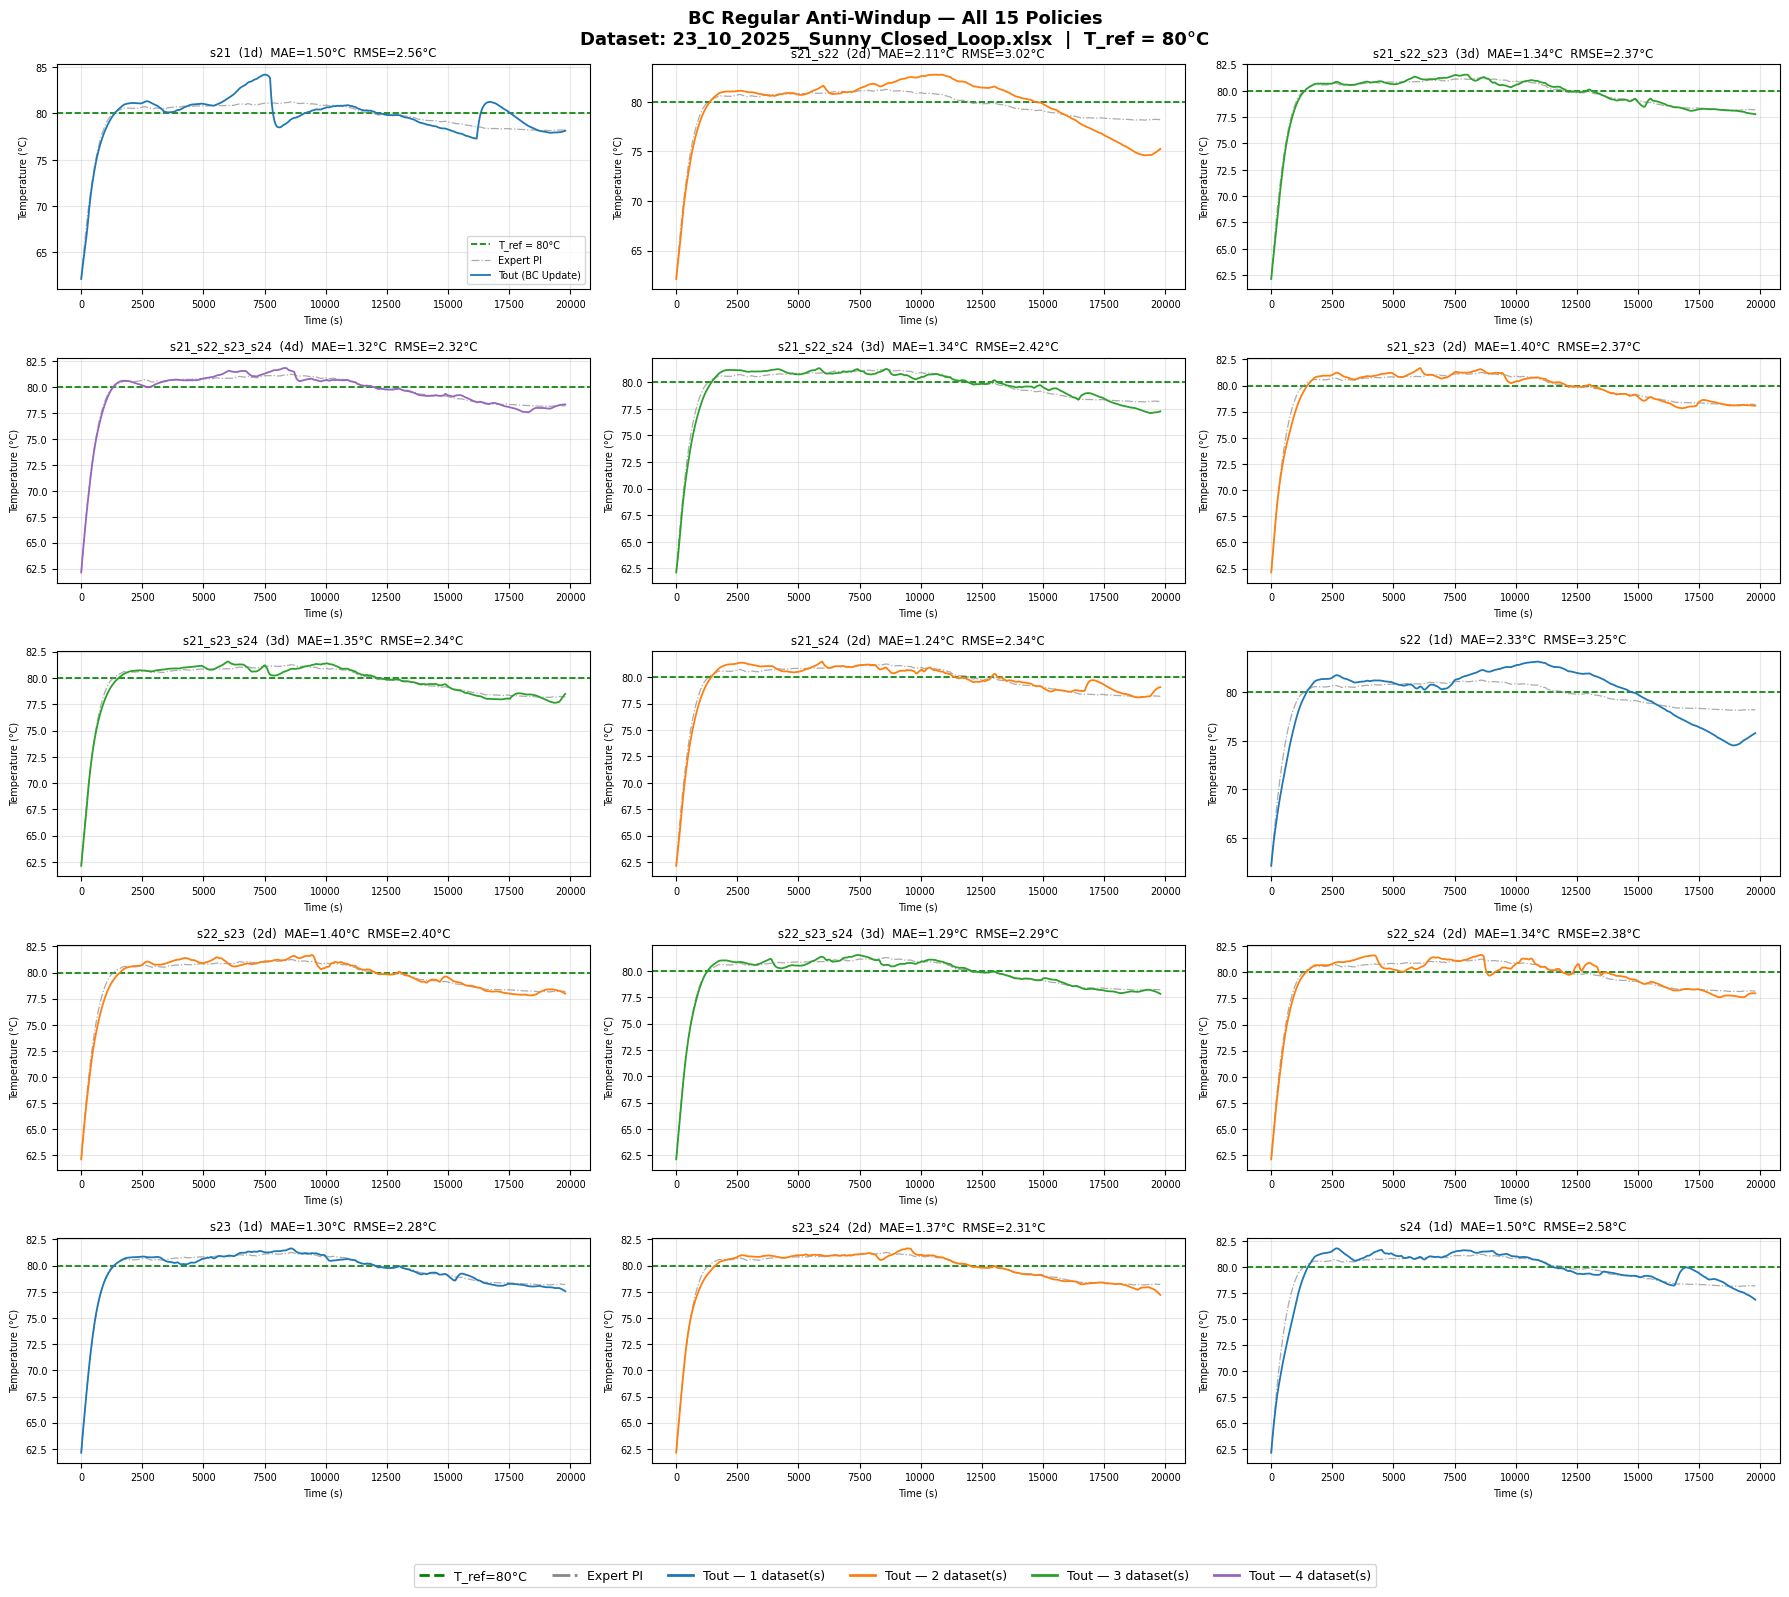

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_s23_80C.png


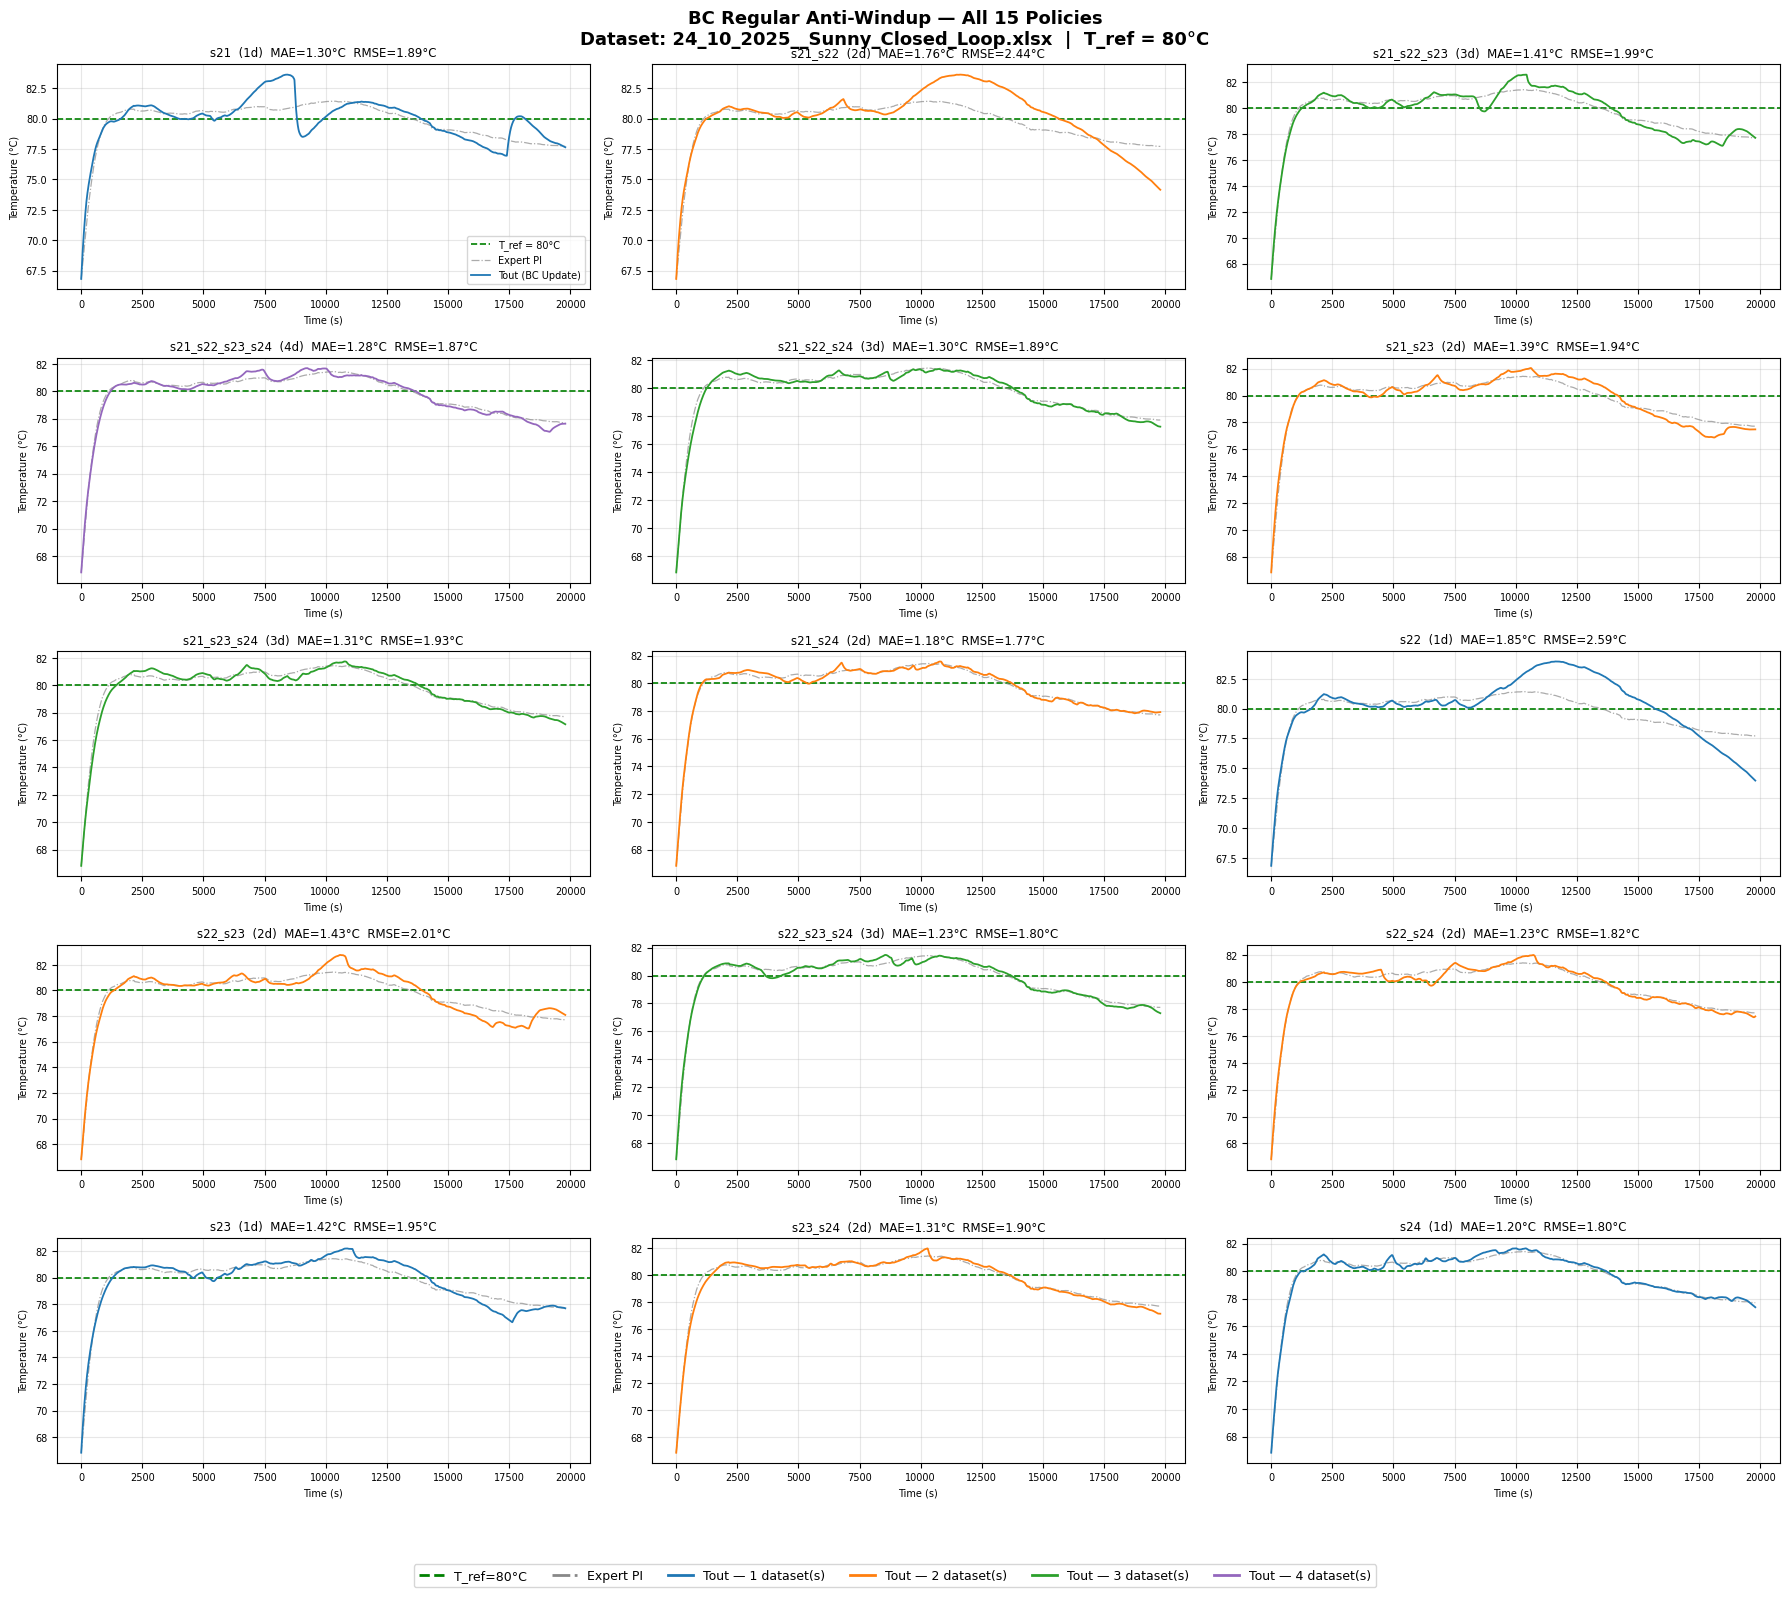

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_grid_s24_80C.png


In [6]:
# ── All policies evaluated on each dataset individually (s20 → s24) ────────────
# Runs all rollouts once, then plots a separate 5×3 grid for each dataset.
ALL_DATASETS_5 = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]
DS_LABELS_5 = ["s20 (65°C)", "s21 (80°C)", "s22 (80°C)", "s23 (80°C)", "s24 (80°C)"]
DS_COLORS_5 = ["#b41f1f", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

# ── Run all rollouts ───────────────────────────────────────────────────────────
print("Running rollouts for all policies on all 5 datasets...")
print("  (T_ref auto-selected: cloudy→65°C, sunny→80°C)\n")
all_results_5 = {}
all_exp_5     = {}

for ds_file, ds_label in zip(ALL_DATASETS_5, DS_LABELS_5):
    ds_data = load_dataset(ds_file)
    Tout_pi, q_pi = rollout_expert(ds_data)
    all_exp_5[ds_label] = {
        'Tout': Tout_pi,
        'tref': dataset_tref(ds_file),
        'time': ds_data['time_ax'][1 : len(Tout_pi) + 1],
    }

for p in policies:
    combo = p['combo_name']
    all_results_5[combo] = {}
    for ds_file, ds_label in zip(ALL_DATASETS_5, DS_LABELS_5):
        ds_data = load_dataset(ds_file)
        tr = dataset_tref(ds_file)
        Tout, q, dq_arr = rollout_bc_regular_anti_windup(p['path'], ds_data)
        err = Tout - tr
        all_results_5[combo][ds_label] = {
            'Tout': Tout, 'error': err, 'tref': tr,
            'mae':  float(np.mean(np.abs(err))),
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'time': ds_data['time_ax'][1 : len(Tout) + 1],
        }
    avg_mae = np.mean([all_results_5[combo][lbl]['mae'] for lbl in DS_LABELS_5])
    print(f"  {combo:22s}  avg MAE={avg_mae:.3f}\u00b0C")

# Best-generalising policy: lowest MAE averaged across ALL 5 datasets
# (not just EVAL_DATASET) so "best" reflects generalisation, matching
# the selection used for the report's summary table.
avg_mae_all = {
    combo: float(np.mean([all_results_5[combo][lbl]['mae'] for lbl in DS_LABELS_5]))
    for combo in all_results_5
}
best_combo_all_ds = min(avg_mae_all, key=avg_mae_all.get)
print(f"\nBest-generalising policy (lowest avg MAE across all 5 datasets): "
      f"{best_combo_all_ds}  (avg MAE={avg_mae_all[best_combo_all_ds]:.4f}\u00b0C)")

print("\nAll rollouts done.")

# ── Per-dataset 5×3 grid ───────────────────────────────────────────────────────
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

for ds_file, ds_label, ds_color in zip(ALL_DATASETS_5, DS_LABELS_5, DS_COLORS_5):
    tr  = dataset_tref(ds_file)
    exp = all_exp_5[ds_label]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
    axes = axes.flatten()

    for idx, p in enumerate(policies):
        combo = p['combo_name']
        ax    = axes[idx]
        r     = all_results_5[combo][ds_label]
        t     = r['time']

        ax.axhline(tr, color='green', linewidth=1.2, linestyle='--',
                   label=f'T_ref = {tr:.0f}°C')
        ax.plot(t, exp['Tout'][:len(r['Tout'])],
                color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7,
                label='Expert PI')
        ax.plot(t, r['Tout'],
                color=GROUP_COLORS.get(p['n_files'], '#333333'), linewidth=1.3,
                label='Tout (BC Update)')
        ax.set_title(
            f"{combo}  ({p['n_files']}d)"
            f"  MAE={r['mae']:.2f}°C  RMSE={r['rmse']:.2f}°C",
            fontsize=8.5,
        )
        ax.set_ylabel('Temperature (°C)', fontsize=7)
        ax.set_xlabel('Time (s)', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='best')

    for ax in axes[len(policies):]:
        ax.set_visible(False)

    from matplotlib.lines import Line2D
    color_handles = [
        Line2D([0],[0], color=GROUP_COLORS[n], linewidth=2, label=f'Tout — {n} dataset(s)')
        for n in sorted(GROUP_COLORS)
    ]
    type_handles = [
        Line2D([0],[0], color='green',   linewidth=2, linestyle='--', label=f'T_ref={tr:.0f}°C'),
        Line2D([0],[0], color='#888888', linewidth=2, linestyle='-.', label='Expert PI'),
    ]
    fig.legend(handles=type_handles + color_handles,
               loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        f'BC Regular Anti-Windup — All {len(policies)} Policies\n'
        f'Dataset: {ds_file}  |  T_ref = {tr:.0f}°C',
        fontsize=13, fontweight='bold',
    )
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    safe_label = ds_label.replace(' ', '_').replace('(', '').replace(')', '').replace('°', '')
    out = os.path.join(CHART_DIR, f'bc_regular_anti_windup_grid_{safe_label}.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")

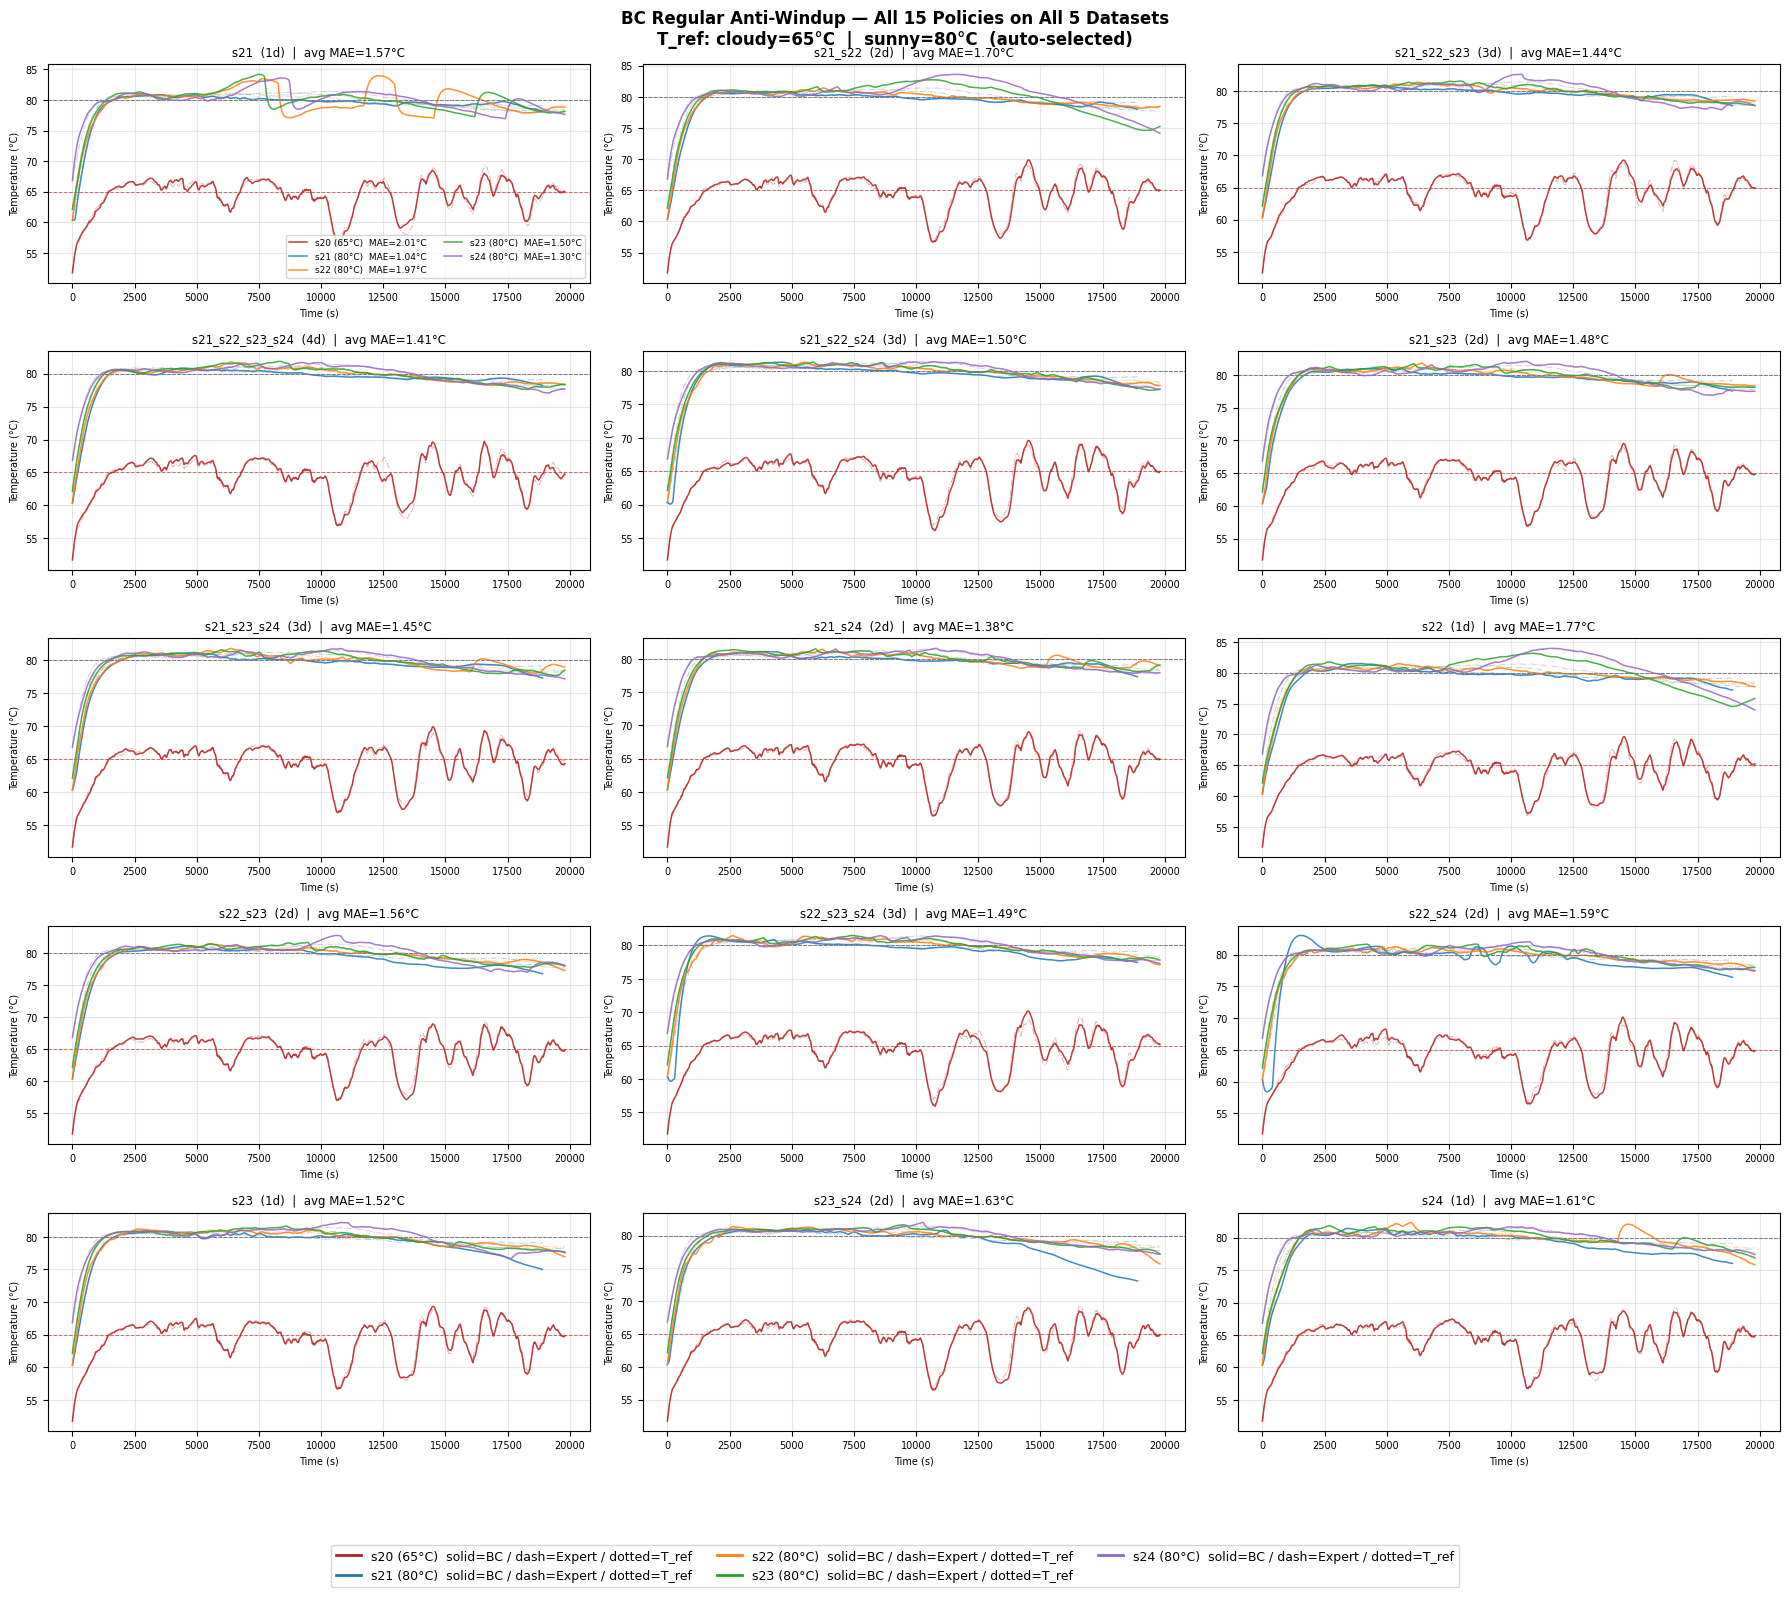

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_all_policies_all_datasets.png


In [7]:
# ── 5×3 grid: all policies — each subplot shows all 5 datasets overlaid ────────
# Uses all_results_5 / all_exp_5 from the cell above — no re-run needed.
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
axes = axes.flatten()

for idx, p in enumerate(policies):
    combo = p['combo_name']
    ax    = axes[idx]
    mae_list = []
    for ds_label, ds_color in zip(DS_LABELS_5, DS_COLORS_5):
        r  = all_results_5[combo][ds_label]
        t  = r['time']
        tr = r['tref']
        ax.axhline(tr, color=ds_color, linewidth=0.7, linestyle='--', alpha=0.6)
        ax.plot(all_exp_5[ds_label]['time'][:len(r['Tout'])],
                all_exp_5[ds_label]['Tout'][:len(r['Tout'])],
                color=ds_color, linewidth=0.7, linestyle='-.', alpha=0.35)
        ax.plot(t, r['Tout'],
                color=ds_color, linewidth=1.1, alpha=0.85,
                label=f'{ds_label}  MAE={r["mae"]:.2f}°C')
        mae_list.append(r['mae'])
    avg_mae = float(np.mean(mae_list))
    ax.set_title(
        f"{combo}  ({p['n_files']}d)  |  avg MAE={avg_mae:.2f}°C",
        fontsize=8.5,
    )
    ax.set_ylabel('Temperature (°C)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=6.5, loc='best', ncol=2)

for ax in axes[len(policies):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
ds_handles = [
    Line2D([0],[0], color=DS_COLORS_5[i], linewidth=2,
           label=f'{DS_LABELS_5[i]}  solid=BC / dash=Expert / dotted=T_ref')
    for i in range(len(DS_LABELS_5))
]
fig.legend(handles=ds_handles,
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    f'BC Regular Anti-Windup — All {len(policies)} Policies on All 5 Datasets\n'
    f'T_ref: cloudy=65°C  |  sunny=80°C  (auto-selected)',
    fontsize=12, fontweight='bold',
)
fig.tight_layout(rect=[0, 0.06, 1, 1])
out = os.path.join(CHART_DIR, 'bc_regular_anti_windup_all_policies_all_datasets.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

In [8]:
# ── Summary table ──────────────────────────────────────────────────────────────
best_combo = best_combo_all_ds  # best-generalising policy (avg MAE across all 5 datasets)
ds_type    = 'cloudy' if TREF == TREF_CLOUDY else 'sunny'

print(f"Evaluated on: {EVAL_DATASET}  |  T_ref = {TREF}°C ({ds_type})\n")
print(f"{'#':>3}  {'Combo':>22}  {'N':>1}  {'MAE (°C)':>10}  "
      f"{'RMSE (°C)':>11}  {'Max |e| (°C)':>13}  "
      f"{'|dq|_mean':>10}  {'dq_std':>8}")
print('-' * 95)
for i, p in enumerate(policies, 1):
    combo = p['combo_name']
    if combo not in results:
        continue
    r      = results[combo]
    marker = '  <- best' if combo == best_combo else ''
    print(f"  {i:>2}  {combo:>22}  {p['n_files']:>1}"
          f"  {r['mae']:>10.4f}  {r['rmse']:>11.4f}  {r['max_e']:>13.4f}"
          f"  {r['dq_mean']:>10.4f}  {r['dq_std']:>8.4f}{marker}")

exp_mae  = float(np.mean(np.abs(err_exp)))
exp_rmse = float(np.sqrt(np.mean(err_exp**2)))
print(f"\nExpert PI baseline  MAE={exp_mae:.4f}°C  RMSE={exp_rmse:.4f}°C  (T_ref={TREF}°C)")
print(f"\nBest BC Regular Anti-Windup policy: {best_combo}")
print(f"  MAE      = {results[best_combo]['mae']:.4f} °C")
print(f"  RMSE     = {results[best_combo]['rmse']:.4f} °C")
print(f"  |dq|_mean= {results[best_combo]['dq_mean']:.4f}")
print(f"  dq_std   = {results[best_combo]['dq_std']:.4f}")

Evaluated on: 20_10_2025__Cloudy_Closed_Loop.xlsx  |  T_ref = 65.0°C (cloudy)

  #                   Combo  N    MAE (°C)    RMSE (°C)   Max |e| (°C)   |dq|_mean    dq_std
-----------------------------------------------------------------------------------------------
   1                     s21  1      2.0149       2.8099        13.2656      0.0120    0.0203
   2                 s21_s22  2      2.2215       3.0469        13.2650      0.0144    0.0233
   3             s21_s22_s23  3      2.1607       2.9515        13.2655      0.0149    0.0249
   4         s21_s22_s23_s24  4      2.1077       2.8717        13.2649      0.0118    0.0213
   5             s21_s22_s24  3      2.2540       3.1121        13.2658      0.0107    0.0190
   6                 s21_s23  2      2.1414       2.9568        13.2651      0.0132    0.0223
   7             s21_s23_s24  3      2.1674       3.0103        13.2659      0.0117    0.0181
   8                 s21_s24  2      2.1804       2.9923        13.2654   

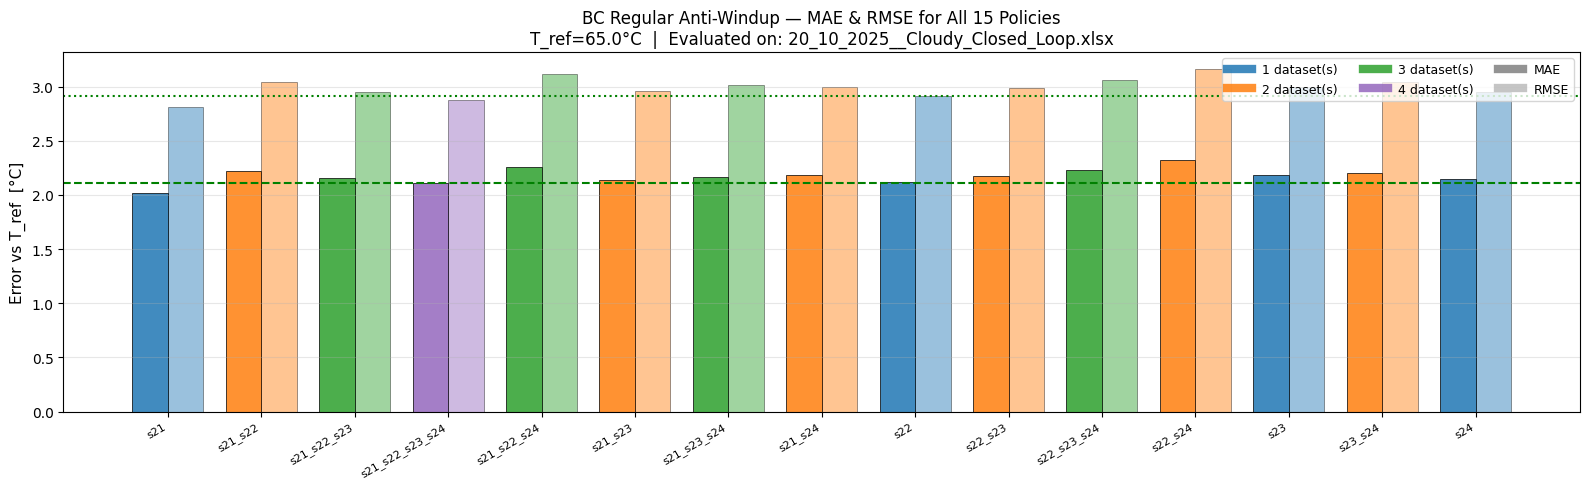

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_mae_rmse_bars_20_10_2025.png


In [9]:
# ── MAE & RMSE bar chart — all policies + Expert PI reference ──────────────────
combos = [p['combo_name'] for p in policies if p['combo_name'] in results]
maes   = [results[c]['mae']  for c in combos]
rmses  = [results[c]['rmse'] for c in combos]
colors = [GROUP_COLORS.get(results[c]['n_files'], '#333333') for c in combos]

x = np.arange(len(combos))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, maes,  width=w, color=colors, alpha=0.85,
       edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, rmses, width=w, color=colors, alpha=0.45,
       edgecolor='black', linewidth=0.6)

exp_mae  = float(np.mean(np.abs(err_exp)))
exp_rmse = float(np.sqrt(np.mean(err_exp ** 2)))
ax.axhline(exp_mae,  color='green', linewidth=1.5, linestyle='--',
           label=f'Expert PI MAE={exp_mae:.3f}°C')
ax.axhline(exp_rmse, color='green', linewidth=1.5, linestyle=':',
           label=f'Expert PI RMSE={exp_rmse:.3f}°C')

ax.set_xticks(x)
ax.set_xticklabels(combos, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Error vs T_ref  [°C]', fontsize=11)
ax.set_title(
    f'BC Regular Anti-Windup — MAE & RMSE for All {len(policies)} Policies\n'
    f'T_ref={TREF}°C  |  Evaluated on: {EVAL_DATASET}',
    fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.lines import Line2D
color_handles = [
    Line2D([0],[0], color=GROUP_COLORS[n], linewidth=6, alpha=0.85, label=f'{n} dataset(s)')
    for n in sorted(GROUP_COLORS)
]
type_handles = [
    Line2D([0],[0], color='grey', linewidth=6, alpha=0.85, label='MAE'),
    Line2D([0],[0], color='grey', linewidth=6, alpha=0.45, label='RMSE'),
]
ax.legend(handles=color_handles + type_handles, fontsize=9, loc='upper right', ncol=3)
fig.tight_layout()
out = os.path.join(CHART_DIR, f'bc_regular_anti_windup_mae_rmse_bars_{EVAL_LABEL}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

Best-generalising policy (lowest avg MAE across all 5 datasets): s21_s24

--- Rendering detail plot for: 20_10_2025__Cloudy_Closed_Loop.xlsx ---


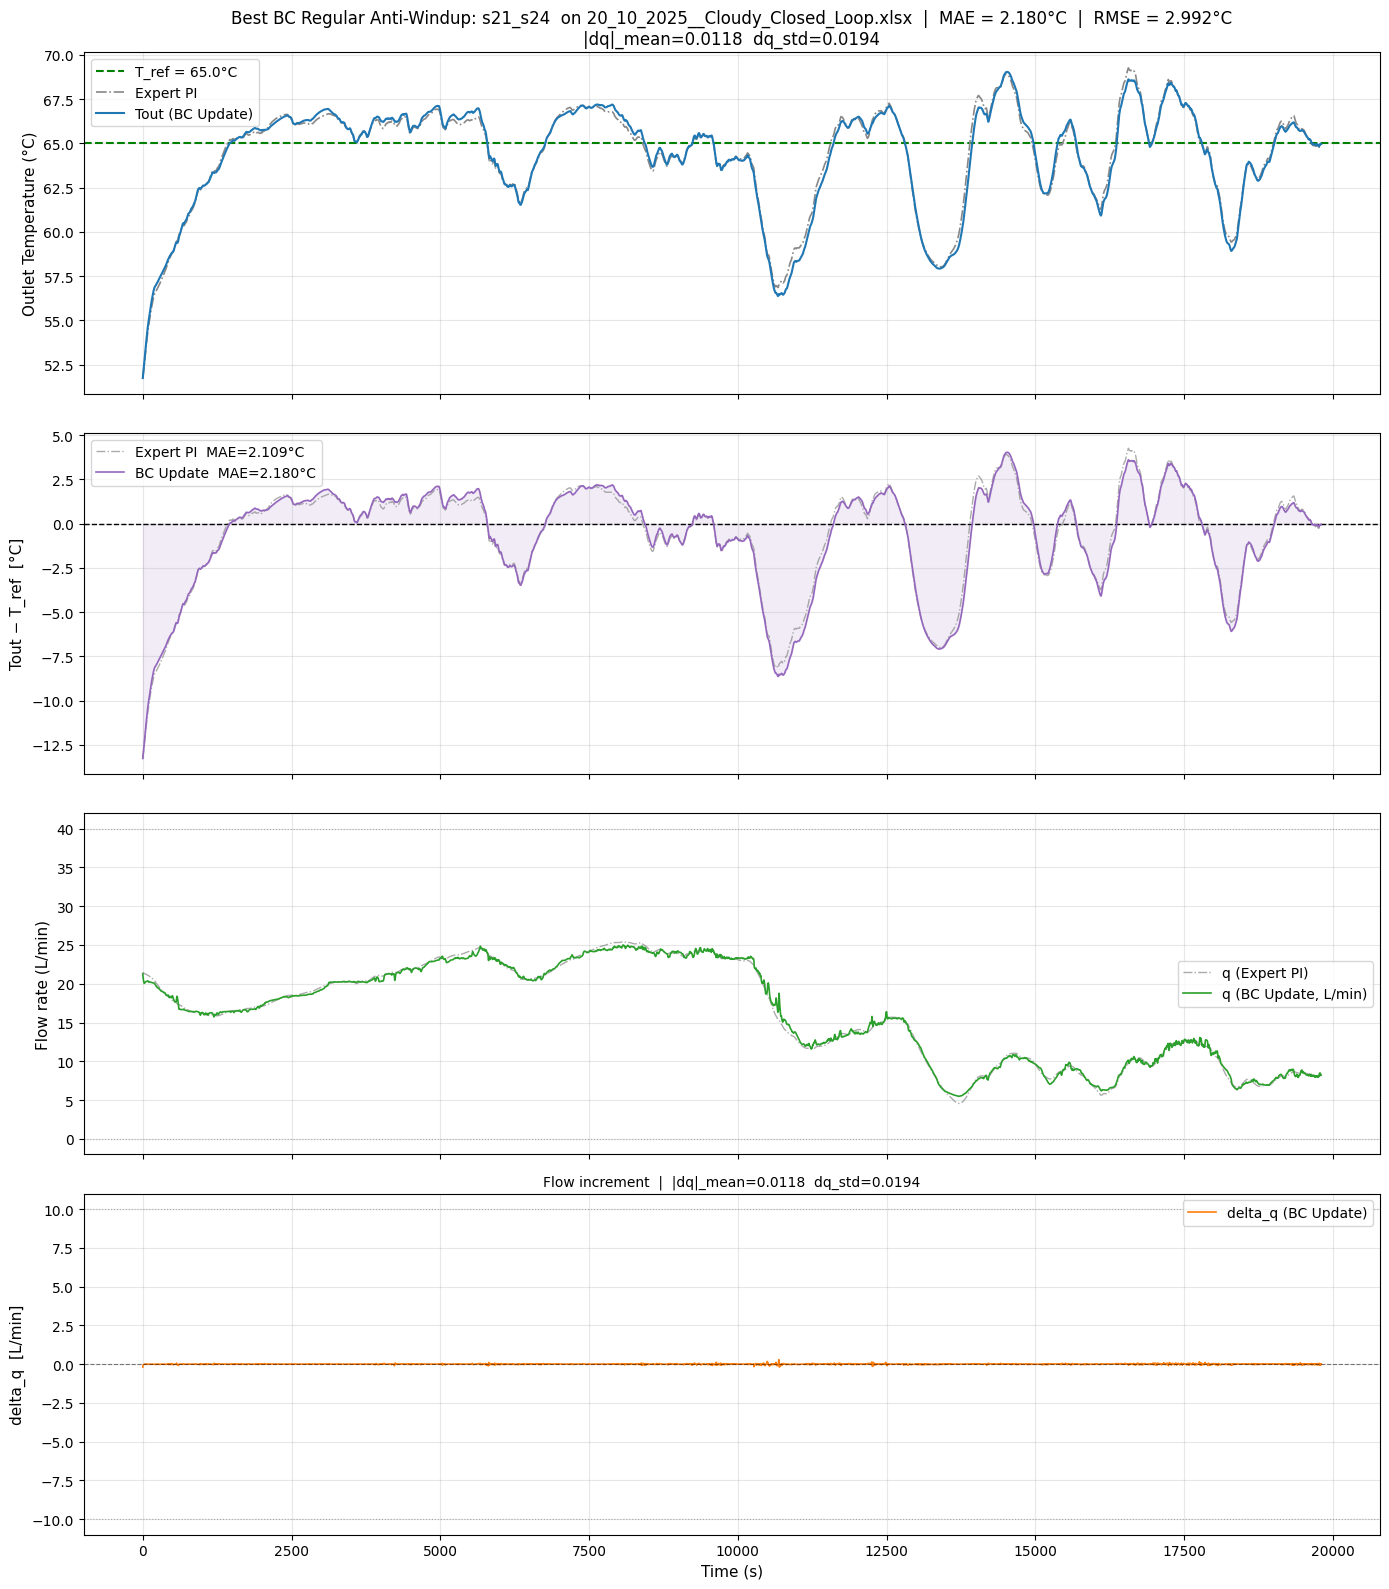

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_detail_20_10_2025.png

--- Rendering detail plot for: 21_10_2025__Sunny_Closed_Loop.xlsx ---


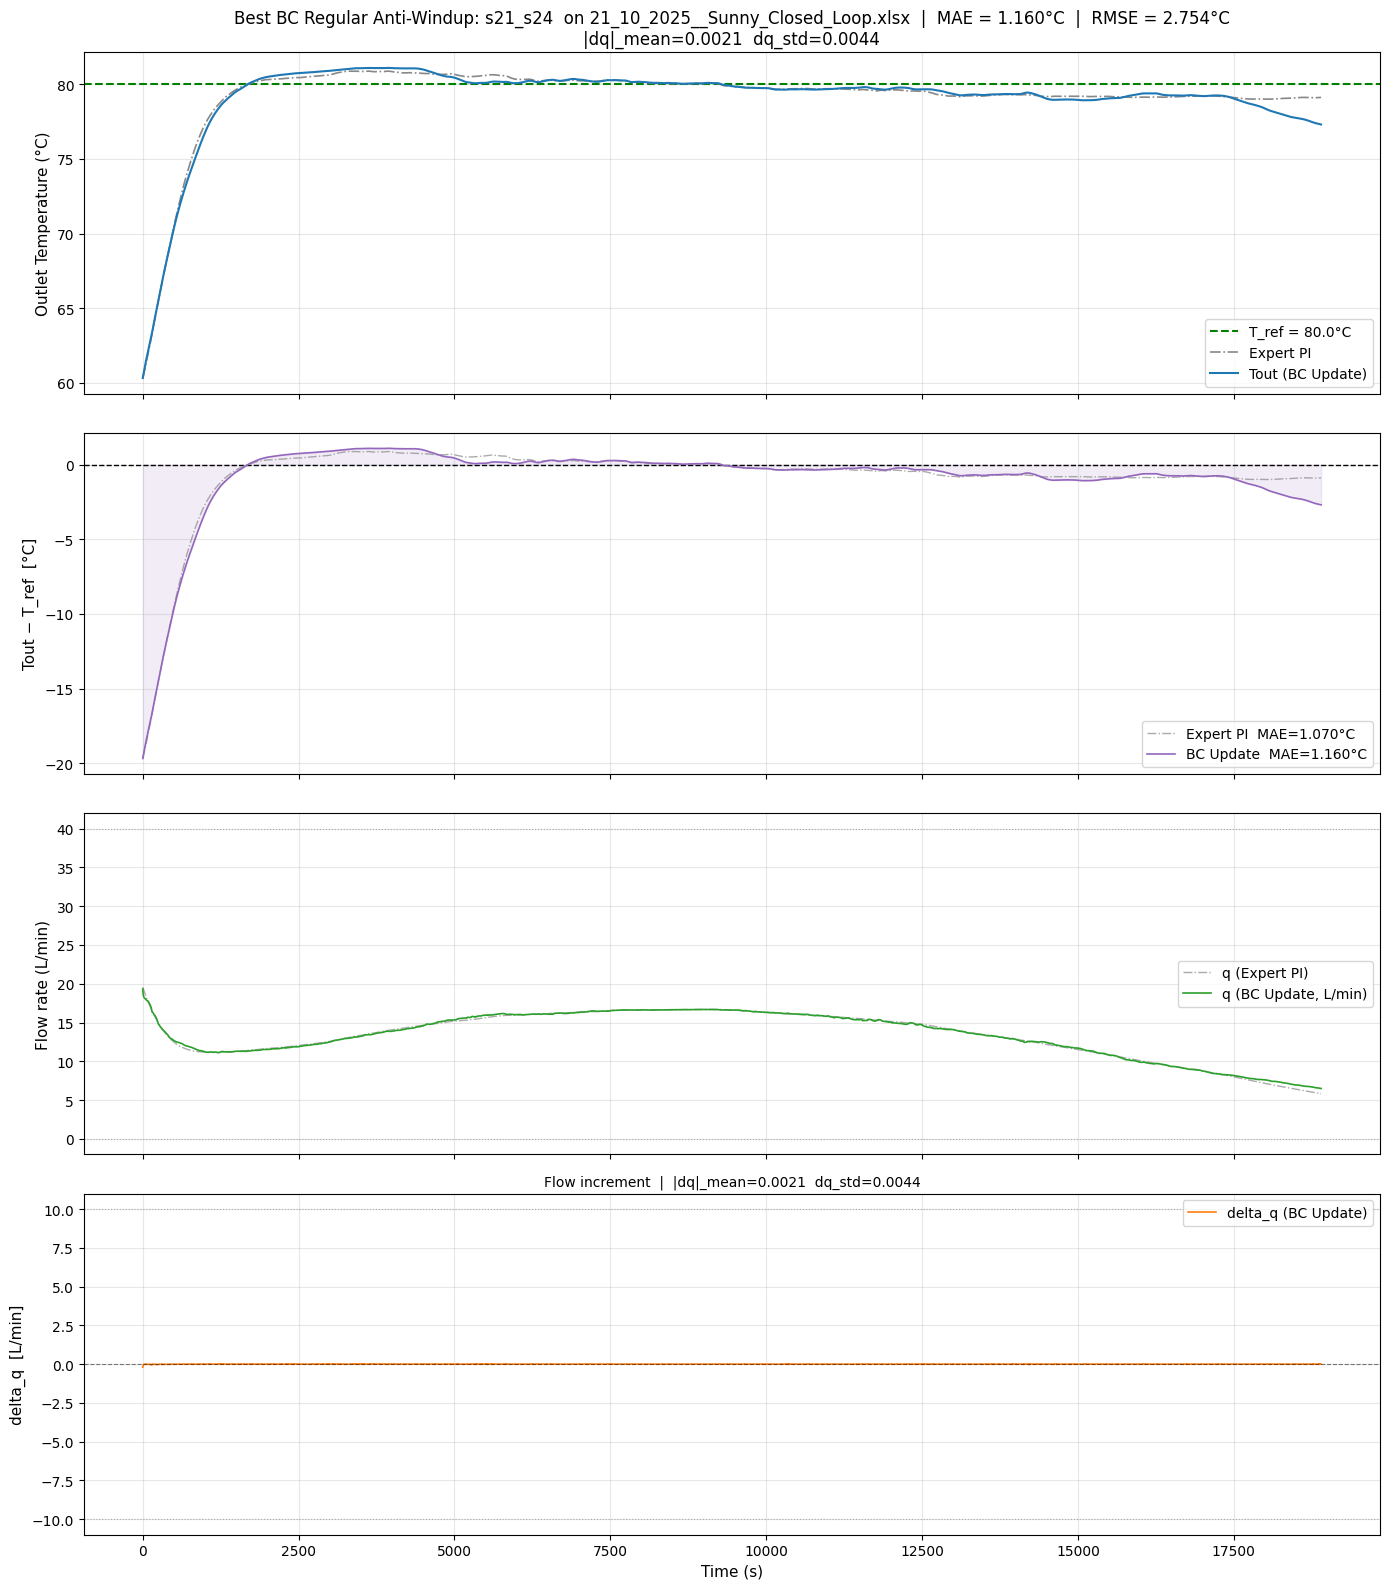

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_detail_21_10_2025.png

--- Rendering detail plot for: 22_10_2025__Sunny_Closed_Loop.xlsx ---


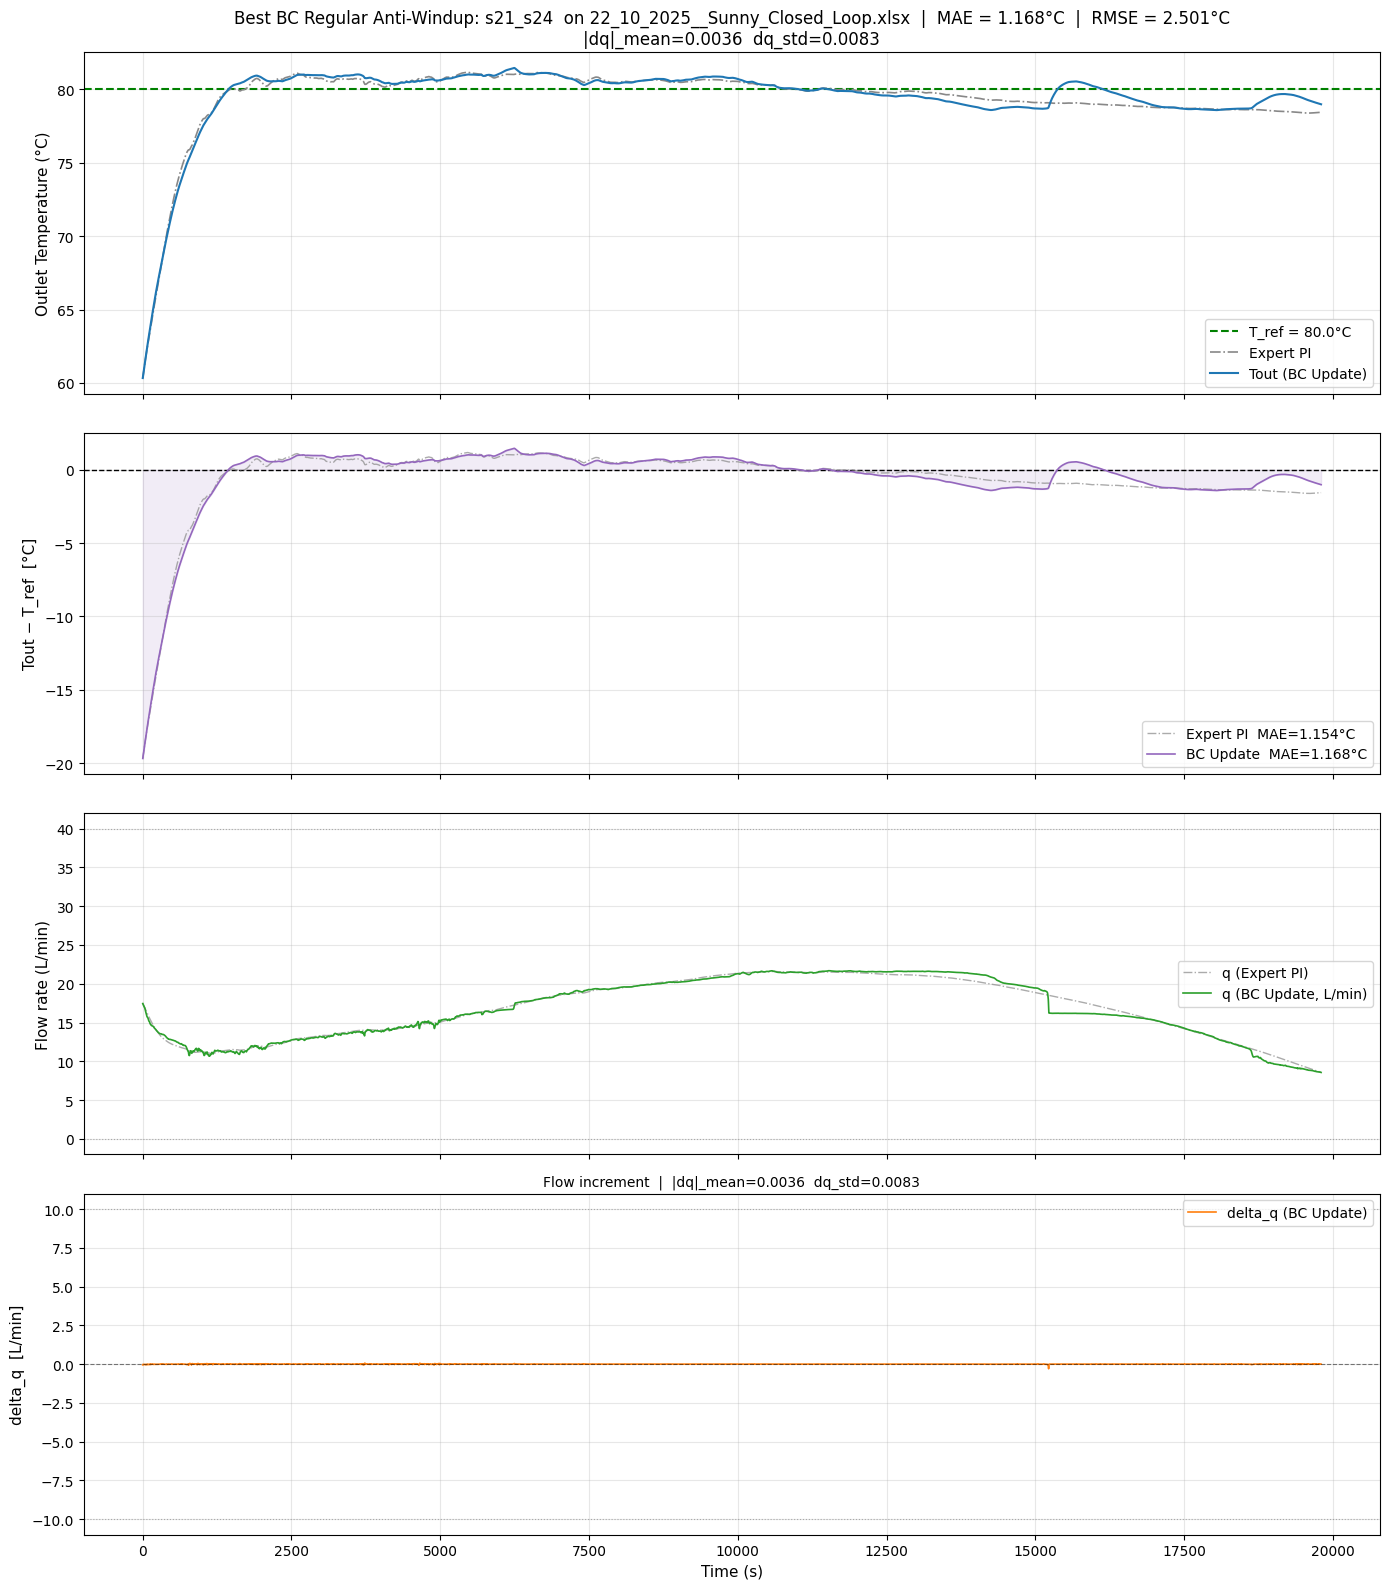

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_detail_22_10_2025.png

--- Rendering detail plot for: 23_10_2025__Sunny_Closed_Loop.xlsx ---


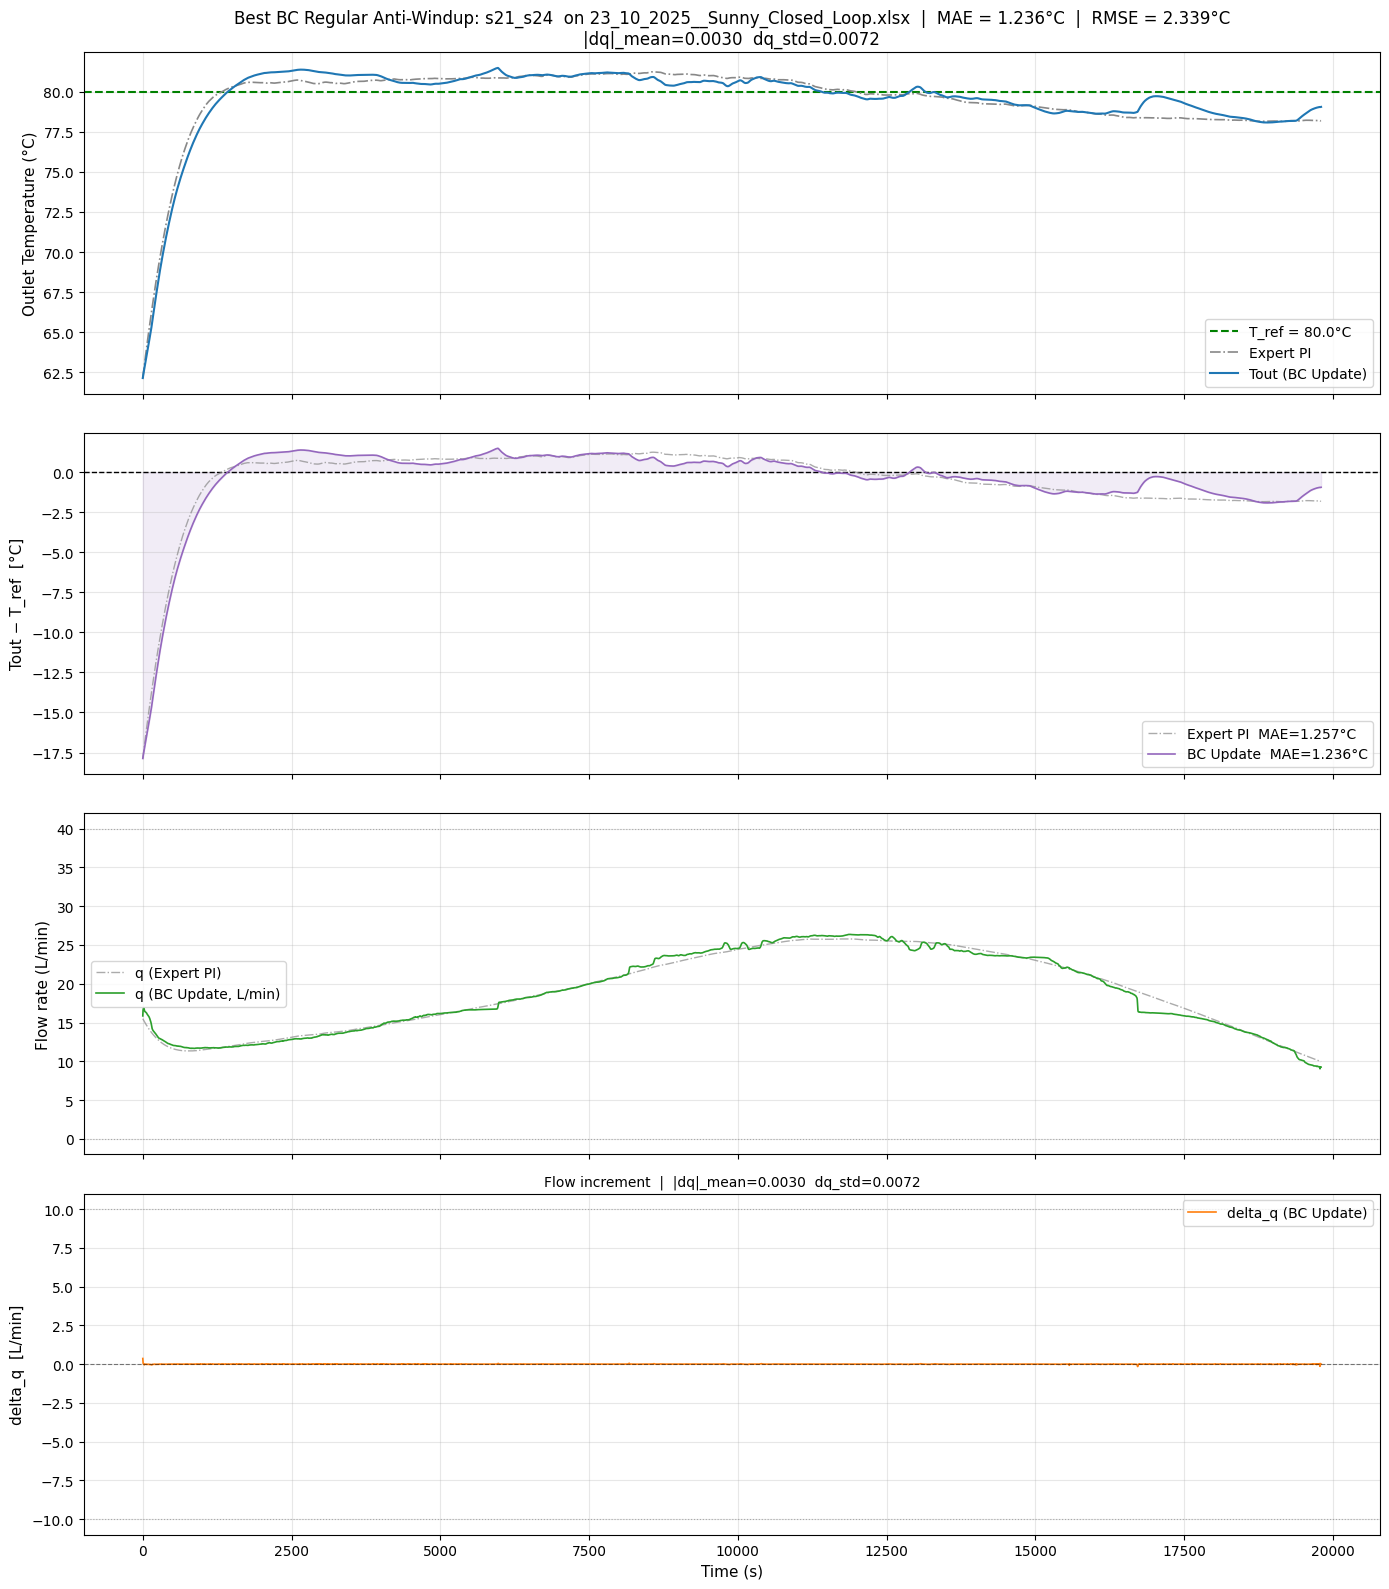

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_detail_23_10_2025.png

--- Rendering detail plot for: 24_10_2025__Sunny_Closed_Loop.xlsx ---


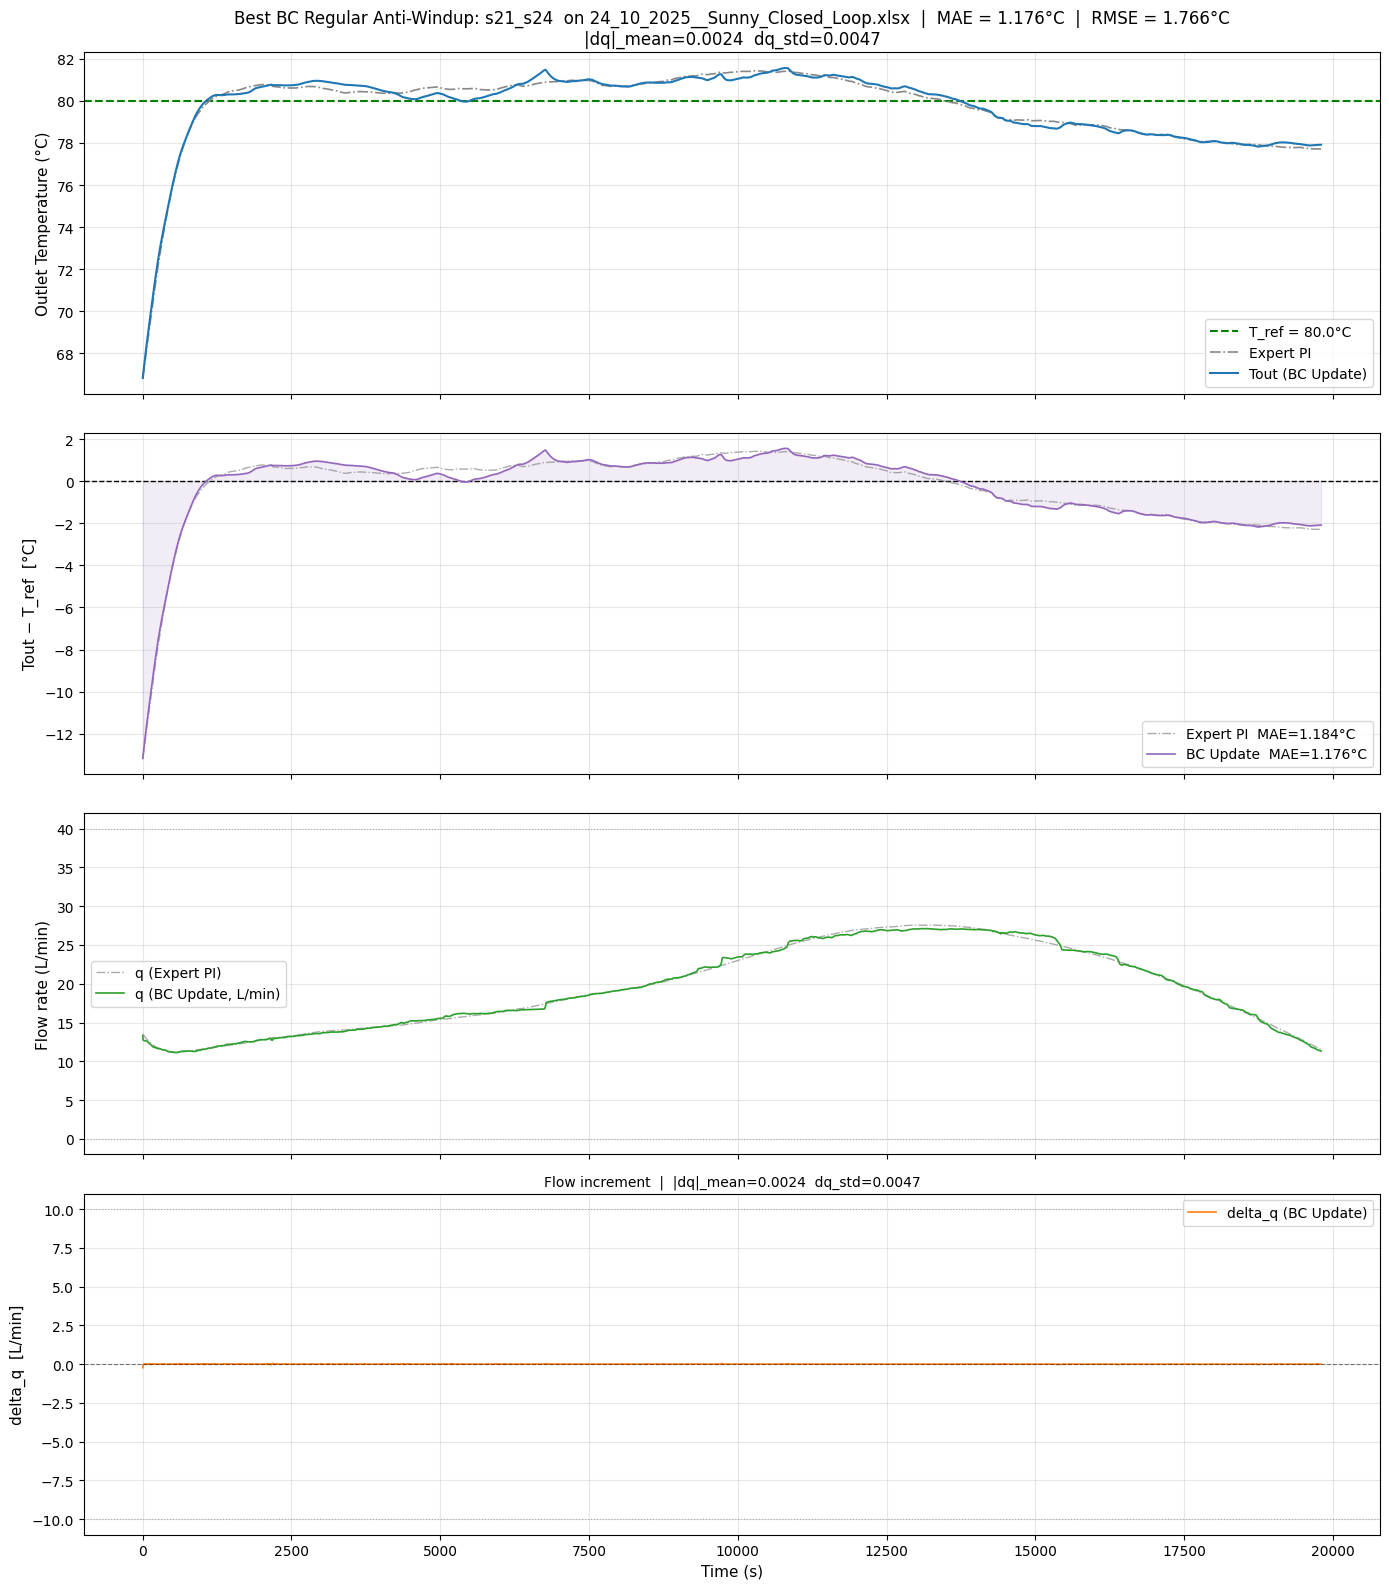

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_detail_24_10_2025.png



In [10]:
# ── Full-size plots for the BEST policy across multiple datasets ──────────────

DATASETS_TO_PLOT = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]

# Guard: results must exist (run the rollout cell first)
if 'results' not in globals() or len(results) == 0:
    raise RuntimeError("`results` is empty — run the rollout cell before this detail cell.")

# 1. Find the best policy overall (outside the loop)
best_combo = best_combo_all_ds   # best-generalising policy (avg MAE across all 5 datasets)
best_path  = os.path.join(SAVE_DIR, f'bc_regular_anti_windup_{best_combo}.pt')
print(f"Best-generalising policy (lowest avg MAE across all 5 datasets): {best_combo}\n")

# 2. Loop through each dataset
for ds_file in DATASETS_TO_PLOT:
    print(f"--- Rendering detail plot for: {ds_file} ---")
    
    # Roll out the best policy + expert on the current dataset
    det_data = load_dataset(ds_file)
    det_tref = dataset_tref(ds_file)
    Tout, q, dq_arr = rollout_bc_regular_anti_windup(best_path, det_data, tref=det_tref)
    Tout_pi, q_pi   = rollout_expert(det_data, tref=det_tref)

    err_bc  = Tout - det_tref
    mae_bc  = float(np.mean(np.abs(err_bc)))
    rmse_bc = float(np.sqrt(np.mean(err_bc ** 2)))
    dq_mean = float(np.mean(np.abs(dq_arr)))
    dq_std  = float(np.std(dq_arr))
    t       = det_data['time_ax'][1 : len(Tout) + 1]

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

    # ── Panel 1: T_ref + Expert PI + BC Update Tout ──
    ax = axes[0]
    ax.axhline(det_tref, color='green', linewidth=1.5, linestyle='--', label=f'T_ref = {det_tref}°C')
    ax.plot(t, Tout_pi[:len(Tout)], color='#888888', linewidth=1.2, linestyle='-.', label='Expert PI')
    ax.plot(t, Tout, color='#1f77b4', linewidth=1.5, label='Tout (BC Update)')
    ax.set_ylabel('Outlet Temperature (°C)', fontsize=11)
    ax.set_title(
        f'Best BC Regular Anti-Windup: {best_combo}  on {ds_file}'
        f'  |  MAE = {mae_bc:.3f}°C  |  RMSE = {rmse_bc:.3f}°C\n'
        f'|dq|_mean={dq_mean:.4f}  dq_std={dq_std:.4f}',
        fontsize=12,
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Tracking error Tout − T_ref ──
    ax = axes[1]
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
    exp_err_clip = Tout_pi[:len(Tout)] - det_tref
    ax.plot(t, exp_err_clip, color='#888888', linewidth=1.0, linestyle='-.', alpha=0.7,
            label=f'Expert PI  MAE={np.mean(np.abs(exp_err_clip)):.3f}°C')
    ax.plot(t, err_bc, color='#9467bd', linewidth=1.2,
            label=f'BC Update  MAE={mae_bc:.3f}°C')
    ax.fill_between(t, err_bc, 0, alpha=0.12, color='#9467bd')
    ax.set_ylabel('Tout − T_ref  [°C]', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── Panel 3: Flow rate q ──
    ax = axes[2]
    ax.plot(t, q_pi[:len(Tout)], color='#888888', linewidth=1.0, linestyle='-.', alpha=0.7,
            label='q (Expert PI)')
    ax.plot(t, q, color='#2ca02c', linewidth=1.2, label='q (BC Update, L/min)')
    ax.axhline(Q_MIN, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.axhline(Q_MAX, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_ylabel('Flow rate (L/min)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── Panel 4: Delta q over time ──
    ax = axes[3]
    ax.plot(t, dq_arr, color='#ff7f0e', linewidth=1.2, label='delta_q (BC Update)')
    ax.axhline(0,      color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline( DQ_MAX, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.axhline(-DQ_MAX, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_ylabel('delta_q  [L/min]', fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_title(f'Flow increment  |  |dq|_mean={dq_mean:.4f}  dq_std={dq_std:.4f}', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    
    # Generate specific filename using the current string (ds_file)
    detail_label = "_".join(ds_file.split("_")[:3])
    out = os.path.join(CHART_DIR, f'bc_regular_anti_windup_best_{best_combo}_detail_{detail_label}.png')
    
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)  # Prevents overlapping/memory leaks in Jupyter/VS Code
    
    print(f"Saved: {out}\n")

Best-generalising policy: s21_s24  (lowest avg MAE across all 5 datasets)
Evaluating on all 5 datasets  (T_ref auto-selected)...



  s20 (65°C) T_ref=65°C:  BC MAE=2.1804°C  RMSE=2.9923°C  Expert MAE=2.1095°C


  s21 (80°C) T_ref=80°C:  BC MAE=1.1602°C  RMSE=2.7539°C  Expert MAE=1.0699°C


  s22 (80°C) T_ref=80°C:  BC MAE=1.1683°C  RMSE=2.5010°C  Expert MAE=1.1537°C


  s23 (80°C) T_ref=80°C:  BC MAE=1.2356°C  RMSE=2.3391°C  Expert MAE=1.2568°C


  s24 (80°C) T_ref=80°C:  BC MAE=1.1765°C  RMSE=1.7664°C  Expert MAE=1.1840°C


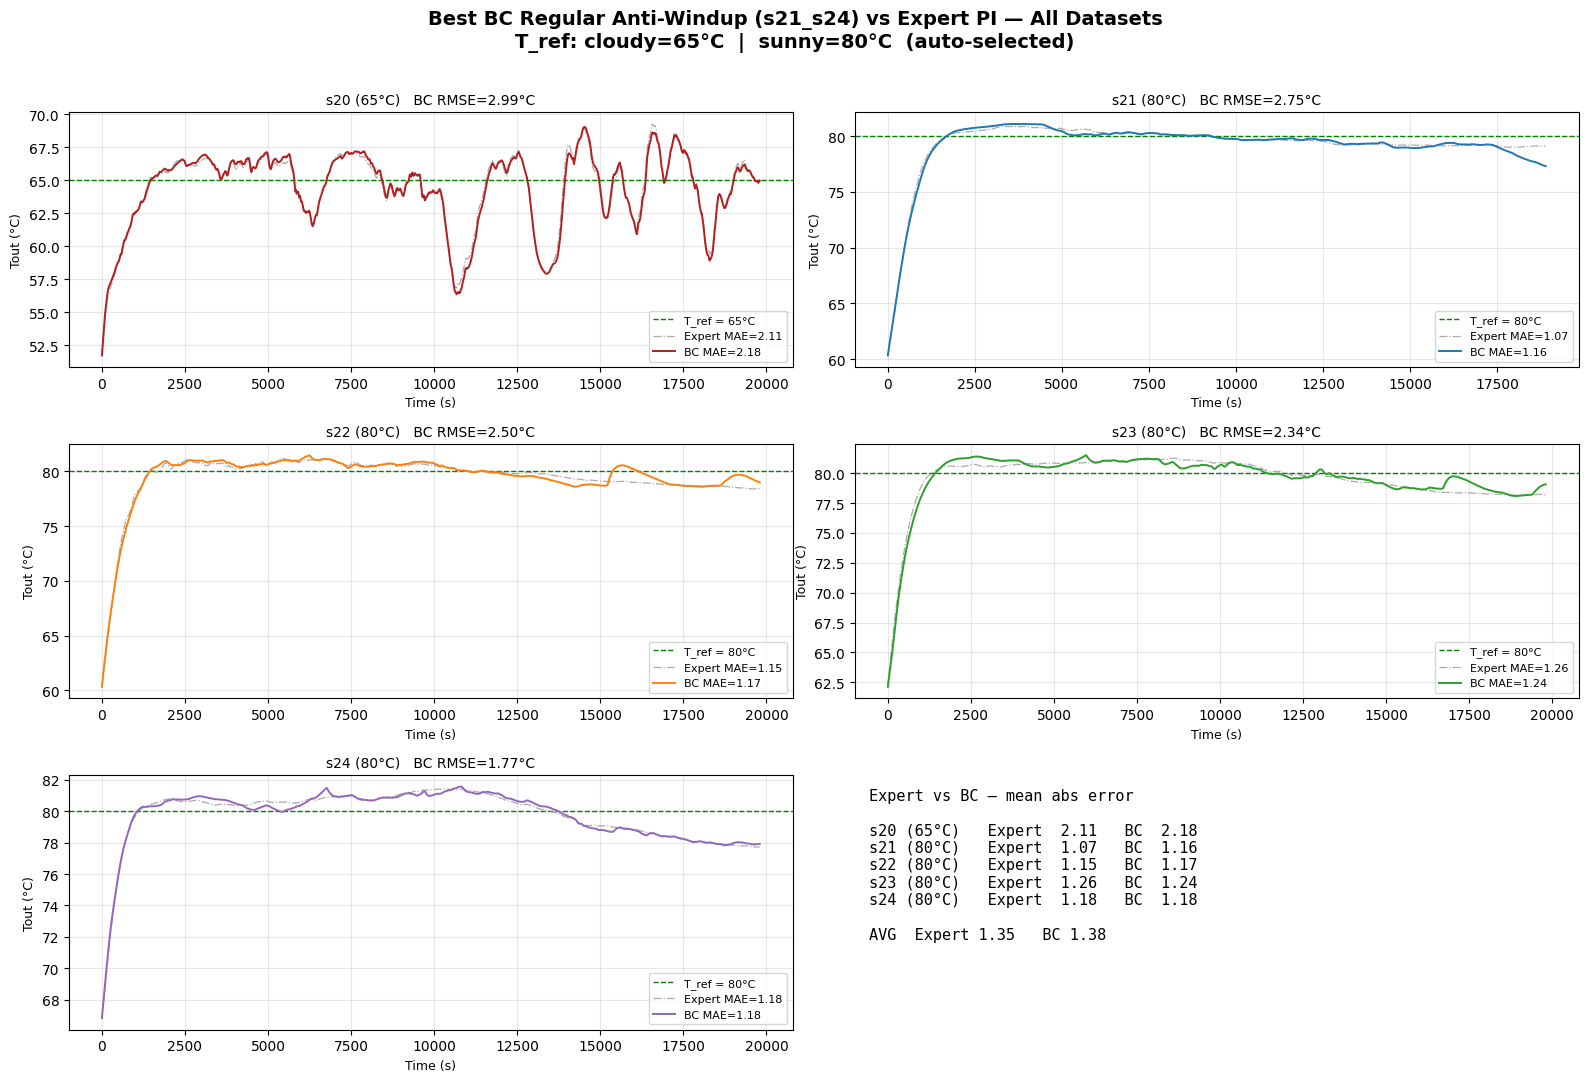


Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\Behavioral Cloning Actor\charts\bc_regular_anti_windup_best_s21_s24_all_datasets.png

Policy: s21_s24  —  performance across all datasets
       Dataset   T_ref      BC MAE     BC RMSE   Expert MAE   |dq|_mean    dq_std
-------------------------------------------------------------------------------------
    s20 (65°C)     65°C      2.1804      2.9923       2.1095      0.0118    0.0194
    s21 (80°C)     80°C      1.1602      2.7539       1.0699      0.0021    0.0044
    s22 (80°C)     80°C      1.1683      2.5010       1.1537      0.0036    0.0083
    s23 (80°C)     80°C      1.2356      2.3391       1.2568      0.0030    0.0072
    s24 (80°C)     80°C      1.1765      1.7664       1.1840      0.0024    0.0047
           AVG               1.3842      2.4705       1.3548


In [11]:
# ── Best policy evaluated on all 5 datasets ────────────────────────────────────
# T_ref is auto-selected per dataset: cloudy → 65°C, sunny → 80°C.
ALL_DATASETS = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]
DS_LABELS = ["s20 (65°C)", "s21 (80°C)", "s22 (80°C)", "s23 (80°C)", "s24 (80°C)"]
DS_COLORS = ["#b41f1f", '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

best_combo = best_combo_all_ds
best_path  = os.path.join(SAVE_DIR, f'bc_regular_anti_windup_{best_combo}.pt')

print(f"Best-generalising policy: {best_combo}  (lowest avg MAE across all 5 datasets)")
print(f"Evaluating on all 5 datasets  (T_ref auto-selected)...\n")

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=False)
axes = axes.flatten()
all_ds_stats = []

for ds_idx, (ds_file, ds_label, ds_color) in enumerate(
        zip(ALL_DATASETS, DS_LABELS, DS_COLORS)):

    ds_data = load_dataset(ds_file)
    tr = dataset_tref(ds_file)

    Tout,    q,    dq_arr  = rollout_bc_regular_anti_windup(best_path, ds_data)
    Tout_pi, q_pi          = rollout_expert(ds_data)

    err_bc  = Tout    - tr
    err_pi  = Tout_pi - tr
    mae_bc  = float(np.mean(np.abs(err_bc)))
    rmse_bc = float(np.sqrt(np.mean(err_bc ** 2)))
    mae_pi  = float(np.mean(np.abs(err_pi)))

    all_ds_stats.append(dict(
        label=ds_label, file=ds_file, tref=tr,
        mae=mae_bc, rmse=rmse_bc, mae_pi=mae_pi,
        dq_mean=float(np.mean(np.abs(dq_arr))),
        dq_std =float(np.std(dq_arr)),
    ))
    print(f"  {ds_label} T_ref={tr:.0f}°C:  "
          f"BC MAE={mae_bc:.4f}°C  RMSE={rmse_bc:.4f}°C  "
          f"Expert MAE={mae_pi:.4f}°C")

    t_ax = ds_data['time_ax'][1 : len(Tout) + 1]
    ax   = axes[ds_idx]
    ax.axhline(tr, color='green', linewidth=1.0, linestyle='--', label=f'T_ref = {tr:.0f}°C')
    ax.plot(t_ax, Tout_pi, color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7,
            label=f'Expert MAE={mae_pi:.2f}')
    ax.plot(t_ax, Tout, color=ds_color, linewidth=1.4,
            label=f'BC MAE={mae_bc:.2f}')
    ax.set_title(f"{ds_label}   BC RMSE={rmse_bc:.2f}°C", fontsize=10)
    ax.set_ylabel('Tout (°C)', fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ── 6th panel (bottom-right): Expert vs BC summary table ───────────────────────
axes[-1].axis('off')
txt = "Expert vs BC — mean abs error\n\n"
for s in all_ds_stats:
    txt += f"{s['label']:<12} Expert {s['mae_pi']:5.2f}   BC {s['mae']:5.2f}\n"
txt += (f"\nAVG  Expert {np.mean([s['mae_pi'] for s in all_ds_stats]):.2f}"
        f"   BC {np.mean([s['mae'] for s in all_ds_stats]):.2f}")
axes[-1].text(0.02, 0.95, txt, va='top', family='monospace', fontsize=11)

fig.suptitle(
    f'Best BC Regular Anti-Windup ({best_combo}) vs Expert PI — All Datasets\n'
    f'T_ref: cloudy=65°C  |  sunny=80°C  (auto-selected)',
    fontsize=14, fontweight='bold',
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
out = os.path.join(CHART_DIR, f'bc_regular_anti_windup_best_{best_combo}_all_datasets.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"\nSaved: {out}")

# ── Cross-dataset summary ──────────────────────────────────────────────────────
print(f"\nPolicy: {best_combo}  —  performance across all datasets")
print(f"{'Dataset':>14}  {'T_ref':>6}  {'BC MAE':>10}  {'BC RMSE':>10}  "
      f"{'Expert MAE':>11}  {'|dq|_mean':>10}  {'dq_std':>8}")
print('-' * 85)
for s in all_ds_stats:
    print(f"  {s['label']:>12}  {s['tref']:>5.0f}°C"
          f"  {s['mae']:>10.4f}  {s['rmse']:>10.4f}  "
          f"{s['mae_pi']:>11.4f}  {s['dq_mean']:>10.4f}  {s['dq_std']:>8.4f}")
print(f"  {'AVG':>12}         "
      f"  {np.mean([s['mae']    for s in all_ds_stats]):>10.4f}  "
      f"{np.mean([s['rmse']   for s in all_ds_stats]):>10.4f}  "
      f"{np.mean([s['mae_pi'] for s in all_ds_stats]):>11.4f}")